<a href="https://colab.research.google.com/github/Dongjin-1203/codeit_mission/blob/main/%EB%AF%B8%EC%85%984_2%ED%8C%80_%EC%A7%80%EB%8F%99%EC%A7%84.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# __스프린트 미션4(정기 예급 가입 여부 예측)__

In [ ]:
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/codeit/data/미션4/bank-additional-full.csv", sep=';')     #그냥 불러오면 제대로 안불러지기 때문에 ;로 구분되어있는걸 분리해줘야 한다.
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [ ]:
df['y'].value_counts()

,count
y,
no,36548
yes,4640


In [ ]:
df['y'] = df['y'].apply(lambda x: 1 if x == 'yes' else 0)

In [ ]:
df['y'].value_counts()

,count
y,
0,36548
1,4640


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [ ]:
df.isna().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


결측값은 없다.

In [ ]:
df.duplicated().sum()

np.int64(12)

중복값 역시 없다

In [ ]:
# 범주형, 수치형 데이터 리스트화(쓸 수 있어서)
columns_numerical = [
    'age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
    'euribor3m', 'nr.employed', 'y'
]
columns_categorical = [
    'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week',
    'poutcome'
]

In [ ]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911,0.112654
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528,0.316173
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000,0.000000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000,0.000000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000,0.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000,0.000000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000,1.000000


In [ ]:
for col in columns_categorical:
    print(f"{col}: {df[col].unique()}\n")

job: ['housemaid' 'services' 'admin.' 'blue-collar' 'technician' 'retired'
 'management' 'unemployed' 'self-employed' 'unknown' 'entrepreneur'
 'student']

marital: ['married' 'single' 'divorced' 'unknown']

education: ['basic.4y' 'high.school' 'basic.6y' 'basic.9y' 'professional.course'
 'unknown' 'university.degree' 'illiterate']

default: ['no' 'unknown' 'yes']

housing: ['no' 'yes' 'unknown']

loan: ['no' 'yes' 'unknown']

contact: ['telephone' 'cellular']

month: ['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'mar' 'apr' 'sep']

day_of_week: ['mon' 'tue' 'wed' 'thu' 'fri']

poutcome: ['nonexistent' 'failure' 'success']



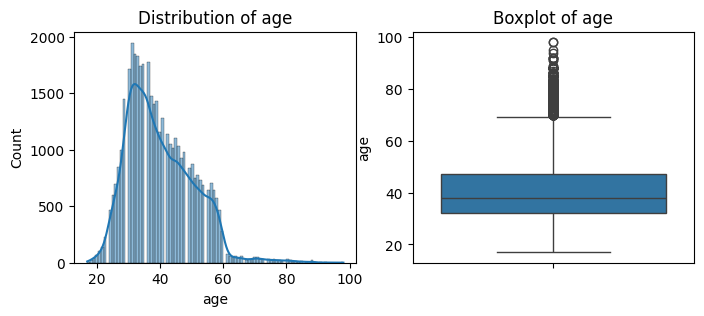

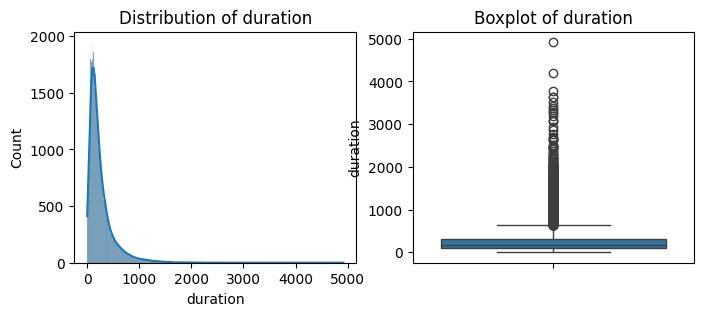

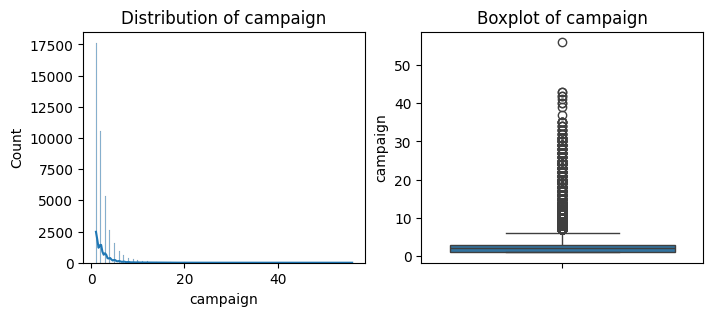

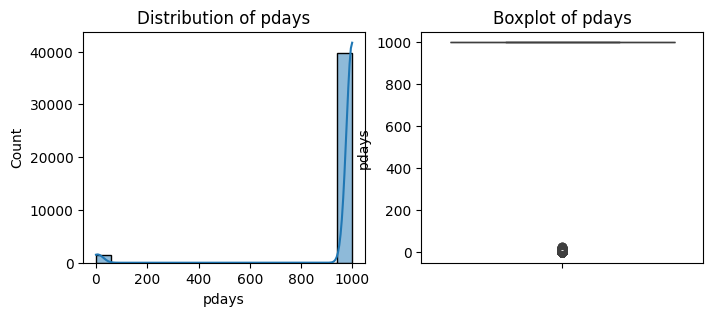

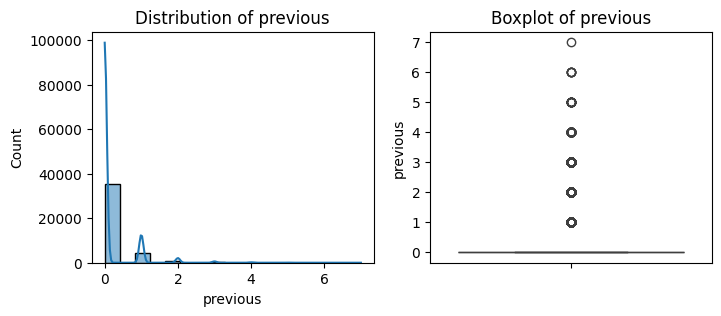

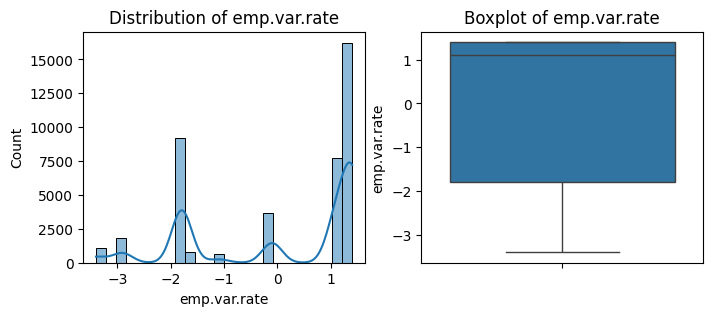

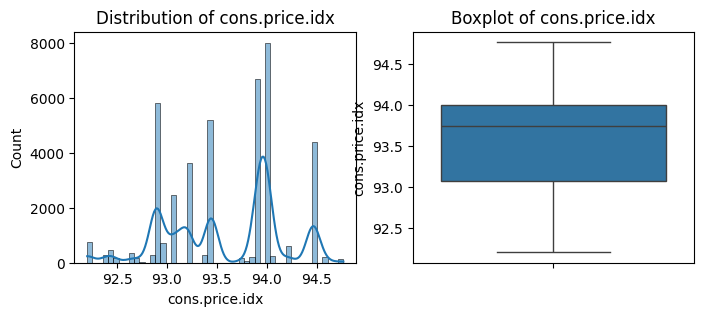

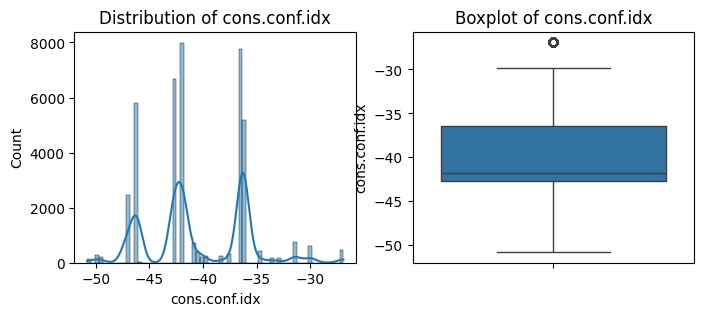

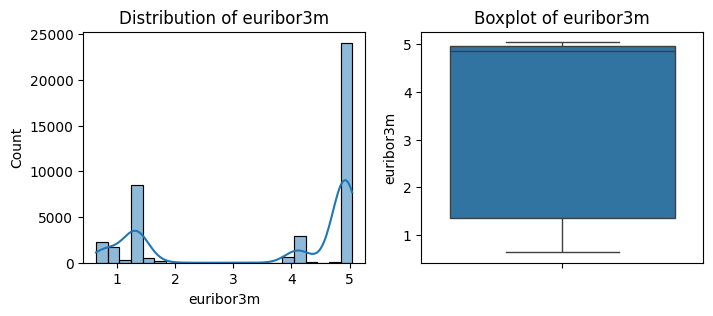

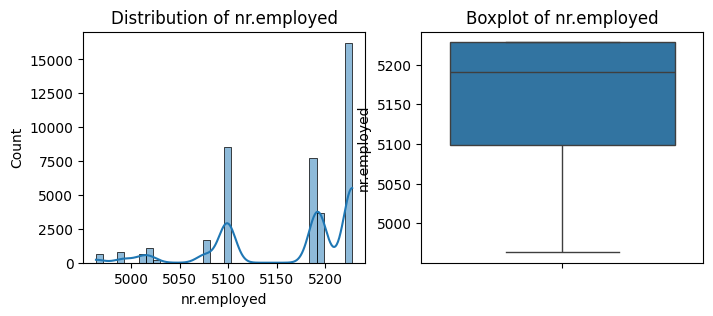

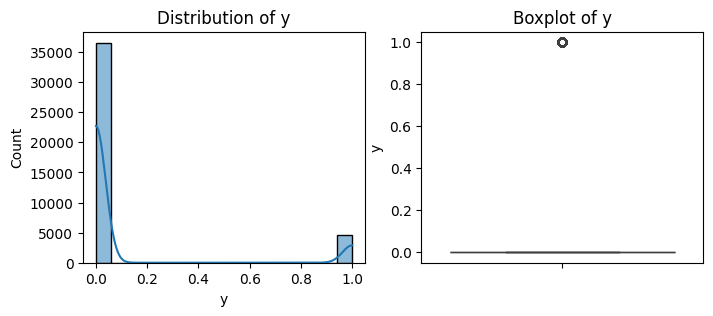

In [ ]:
# 데이터 분포
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()
# numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()[:-1]    # target 빼고

for feature in columns_numerical:
    plt.figure(figsize=(8, 3))
    plt.subplot(1, 2, 1)
    sns.histplot(df[feature], kde=True)
    plt.title('Distribution of ' + feature)
    plt.subplot(1, 2, 2)
    sns.boxplot(y=df[feature])
    plt.title('Boxplot of ' + feature)
    plt.show()

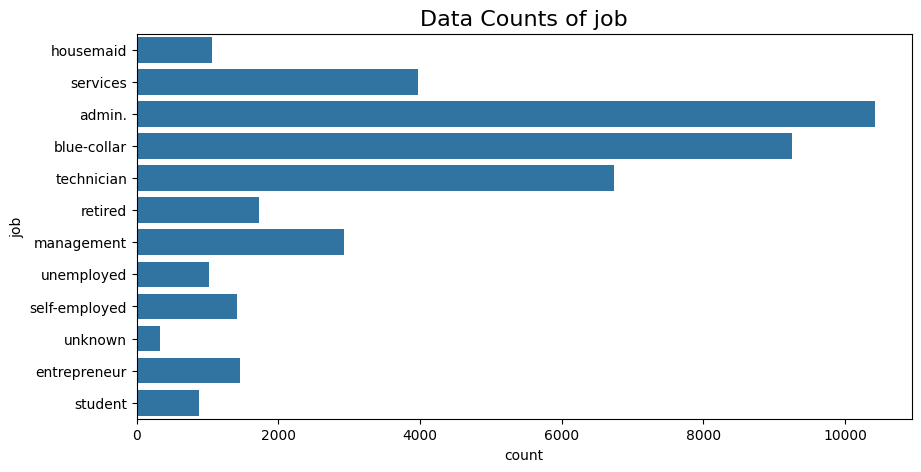

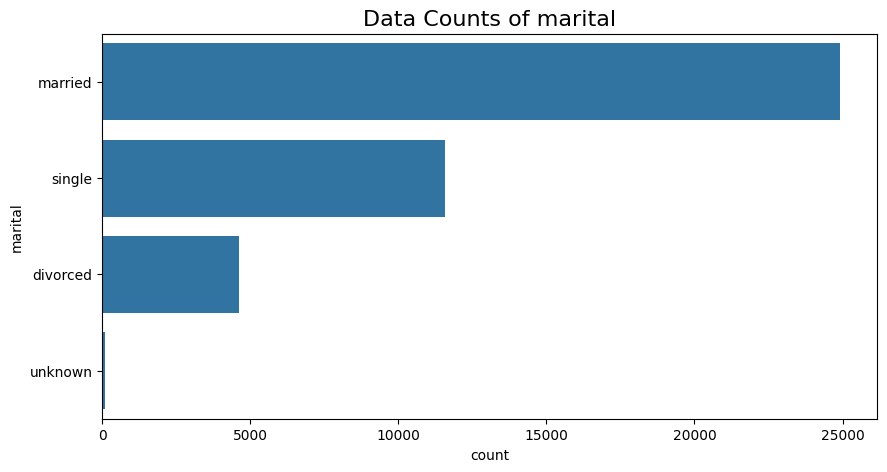

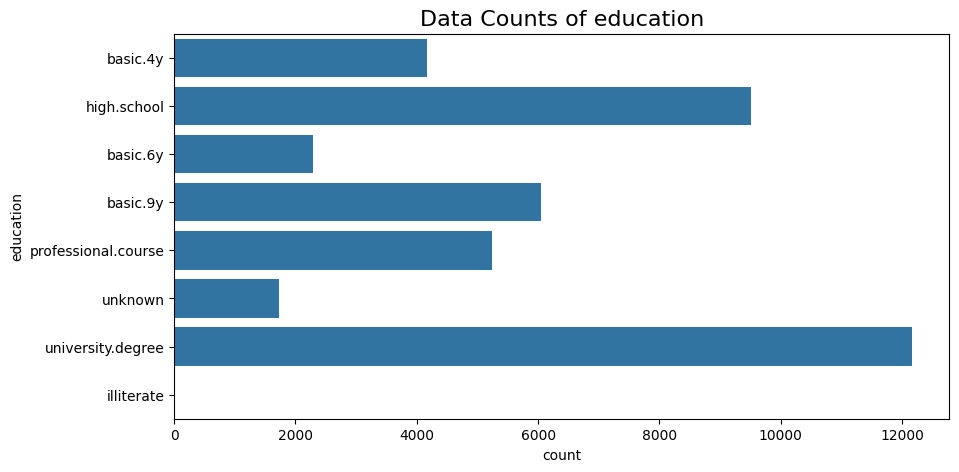

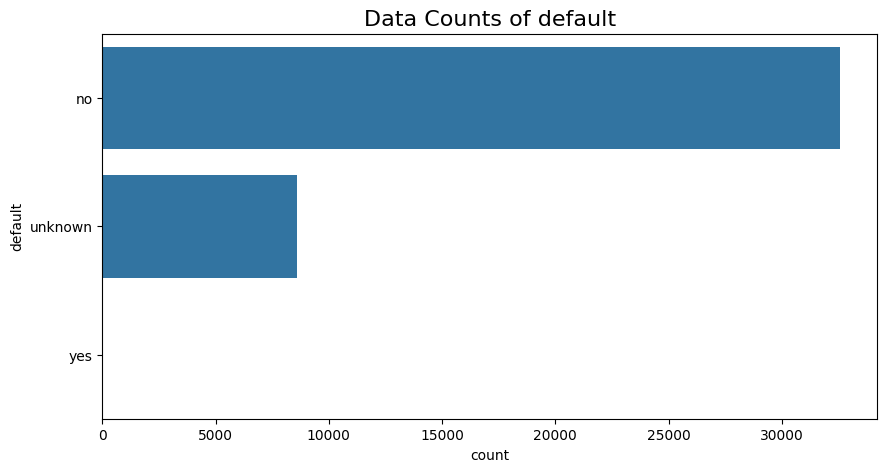

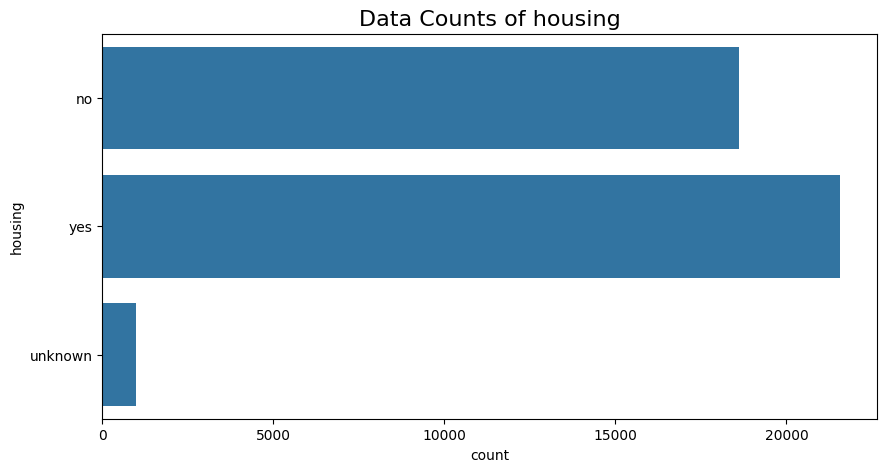

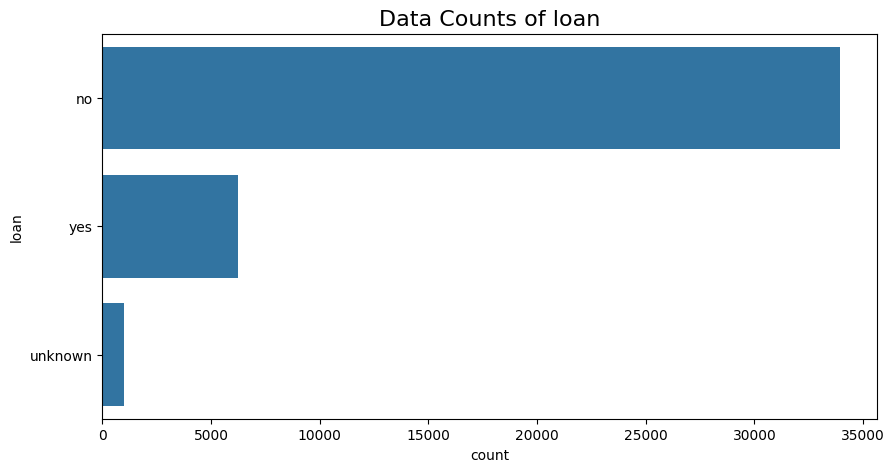

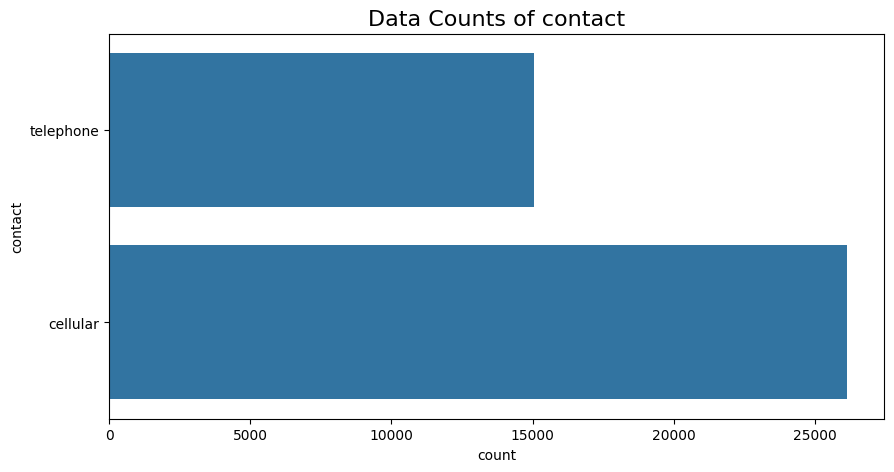

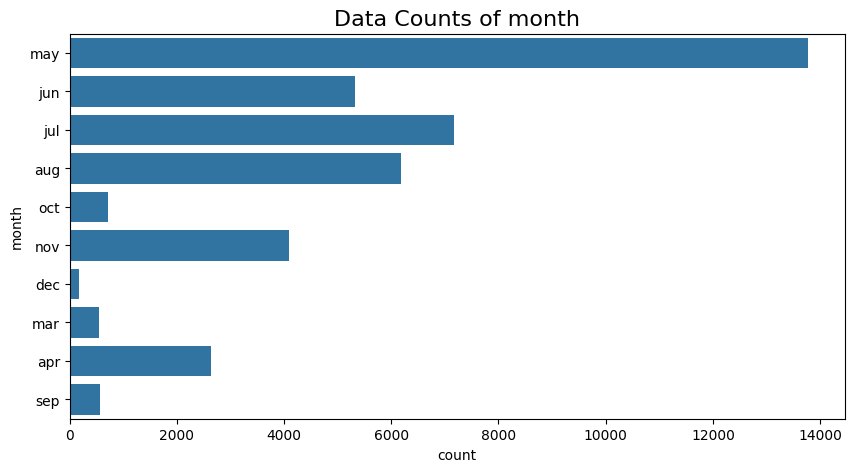

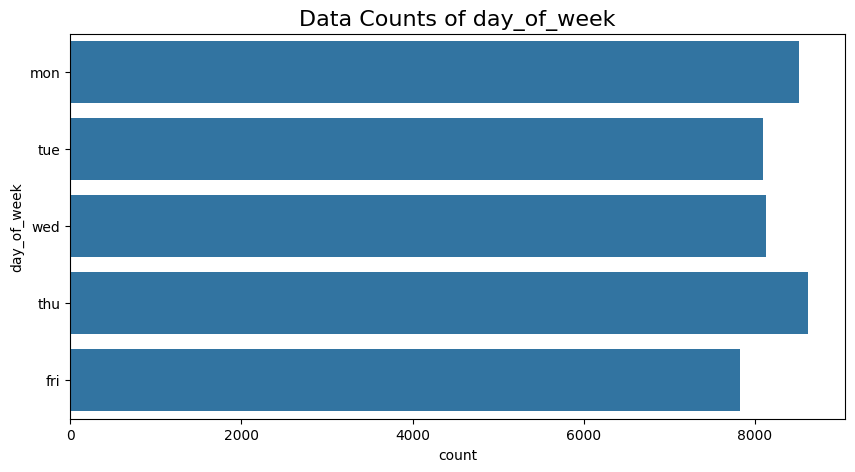

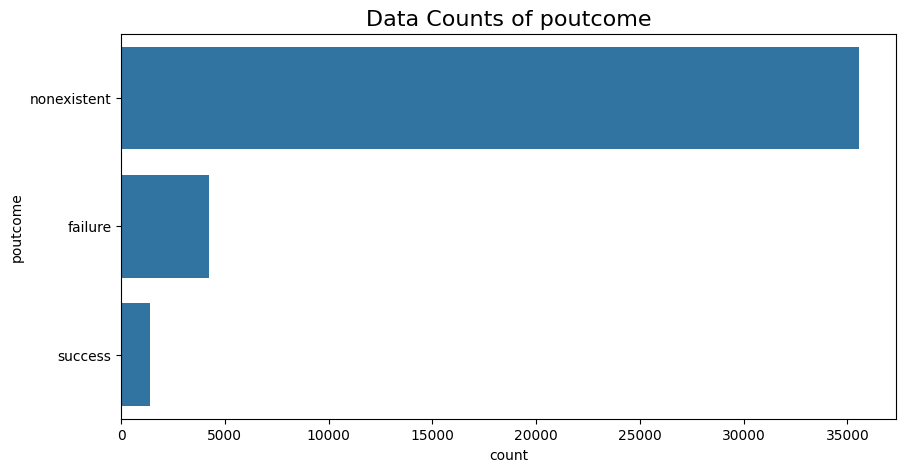

In [ ]:
# 범주형 데이터 확
for feature in columns_categorical:
    plt.figure(figsize=(10, 5))
    sns.countplot(df[feature])
    plt.title('Data Counts of '+ feature, fontsize=16)
    plt.show()

수치형 데이터의 분포이다.

하위는 전체 데이터에 대한 설명이다.

1.	age (숫자형): 나이
2.	job (범주형): 직업 종류
o	admin., blue-collar, entrepreneur, housemaid, management, retired, self-employed, services, student, technician, unemployed, unknown
3.	marital (범주형): 결혼 여부
o	divorced, married, single, unknown
※ divorced는 이혼 또는 사별 포함
4.	education (범주형): 교육 수준
o	basic.4y, basic.6y, basic.9y, high.school, illiterate, professional.course, university.degree, unknown
5.	default (범주형): 연체 기록 여부 ("yes", "no", "unknown")
6.	housing (범주형): 주택담보대출 여부
7.	loan (범주형): 개인대출 여부

🔸 8~11: 마지막 마케팅 접촉 관련 정보
8.	contact (범주형): 통신 수단 ("cellular", "telephone")
9.	month (범주형): 마지막 통화 월
10.	day_of_week (범주형): 마지막 통화 요일
11.	duration (숫자형): 마지막 통화 시간 (초 단위)

⚠ 중요한 주의 사항:
이 속성은 예측 타겟인 y에 큰 영향을 줍니다.
예: duration = 0이면 대부분 y = "no"임.
하지만 duration은 전화를 걸기 전에는 알 수 없고,
통화 후엔 y값도 이미 알려진 상태이기 때문에,
→ 실제 예측 모델에서는 제외해야 하며,
→ 벤치마크용 실험일 때만 포함하세요.

🔸 12~15: 캠페인 히스토리 관련
12.	campaign: 현재 캠페인에서 고객에게 연락한 횟수
13.	pdays: 지난 캠페인 이후 며칠 만에 다시 연락했는가 (999 = 이전에 연락 없음)
14.	previous: 이전 캠페인에서 연락한 횟수
15.	poutcome (범주형): 지난 캠페인의 결과 ("failure", "nonexistent", "success")

🔸 16~20: 사회·경제 지표 (전국 단위)
16.	emp.var.rate: 고용 변화율 (분기별 지표)
17.	cons.price.idx: 소비자물가지수 (월간 지표)
18.	cons.conf.idx: 소비자 신뢰지수 (월간 지표)
19.	euribor3m: 유로존 3개월 금리 (일일 지표)
20.	nr.employed: 고용자 수 (분기별 지표)


🎯 출력 변수:
21.	y (범주형/수치형): 고객이 정기예금에 가입했는가?
- 값: "yes"(1) 또는 "no"(0)

# 분석 목표

어떤 사람의 데이터를 보고 정기예금 가입 여부를 예측하자.

생각을 했을때 내가 어떤 조건이면 예금가입을 할지 고민을 해보자.

고민했을 때 내가 판단한 요인은 다음과 같다.

 1. age(수치): 어느정도 나이가 되면 어떤 목적에 의해 가입을 할 것이다.
 2. job(범주): 직업에 따라 예금을 가입 안할 수도?
 3. marital(범주): 결혼을 했다하면 자녀양육, 노후준비를 위한 예금가입을 할 것 같다.
 4. education(범주): 일정 수준 이상의 교육을 수료하였다면 예금을 가입하려는 경향이 있지 않을까?
 5. default(범주): 연채기록이 있다면 경제적인 이유가 있을 수 있다.
 6. housing(범주): 주택담보대출이 있다면 예금정도는 가입할 수 있을 듯?
 7. loan(범주): 대출도 능력이 되어야 받을 수 있고 자금관리가 어느정도 되는 사람 일 수 있다.
 8. poutcome(범주): 보통은 텔레마케팅으로 좋은 성과를 거두긴 힘들다. 하지만 성공을 한 적이 있다면 또 한번 기대해봐도 좋을 것 같다.
 9. emp.var.rate(수치): 고용이 많이 되어 경제활동을 하는 인구가 늘어난다면 저축을 또 하지 않을까?
 10. cons.price.idx(수치): 소비자 물가가 올라간다면 심리상 저축을 좀더 하려고 할 것이다.
 11. cons.conf.idx(수치): 소비자가 경제가 불안정하다 느끼면 더 저축하려고 할 것 같다.
 12. euribor3m(수치): 금리가 내려가는 상황이라면 경제가 않좋은 경우가 많으니 더 저축하려고 할 것이다.
 13. nr.employed(수치): 고용자 수가 많으면 예금을 들으려는 사람이 늘어날 것이다.

생각한대로 한번 모델을 만들어 보자

# 초기 모델 제작(일부 데이터 제거)

In [ ]:
df_1_cols = ['age', 'job', 'marital', 'education', 'default',
             'housing', 'loan', 'poutcome', 'emp.var.rate', 'cons.price.idx',
             'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']
df_1 = df[df_1_cols]
df_1.head()

,age,job,marital,education,default,housing,loan,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
1,57,services,married,high.school,unknown,no,no,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
2,37,services,married,high.school,no,yes,no,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
3,40,admin.,married,basic.6y,no,no,no,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
4,56,services,married,high.school,no,no,yes,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0


범주형 변수 처리

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

object_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'poutcome']

for ob in object_cols:
    df_1[ob] = encoder.fit_transform(df_1[ob])
df_1.head()

/tmp/ipython-input-16-489829252.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_1[ob] = encoder.fit_transform(df_1[ob])
/tmp/ipython-input-16-489829252.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_1[ob] = encoder.fit_transform(df_1[ob])
/tmp/ipython-input-16-489829252.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-

,age,job,marital,education,default,housing,loan,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,3,1,0,0,0,0,1,1.1,93.994,-36.4,4.857,5191.0,0
1,57,7,1,3,1,0,0,1,1.1,93.994,-36.4,4.857,5191.0,0
2,37,7,1,3,0,2,0,1,1.1,93.994,-36.4,4.857,5191.0,0
3,40,0,1,1,0,0,0,1,1.1,93.994,-36.4,4.857,5191.0,0
4,56,7,1,3,0,0,2,1,1.1,93.994,-36.4,4.857,5191.0,0


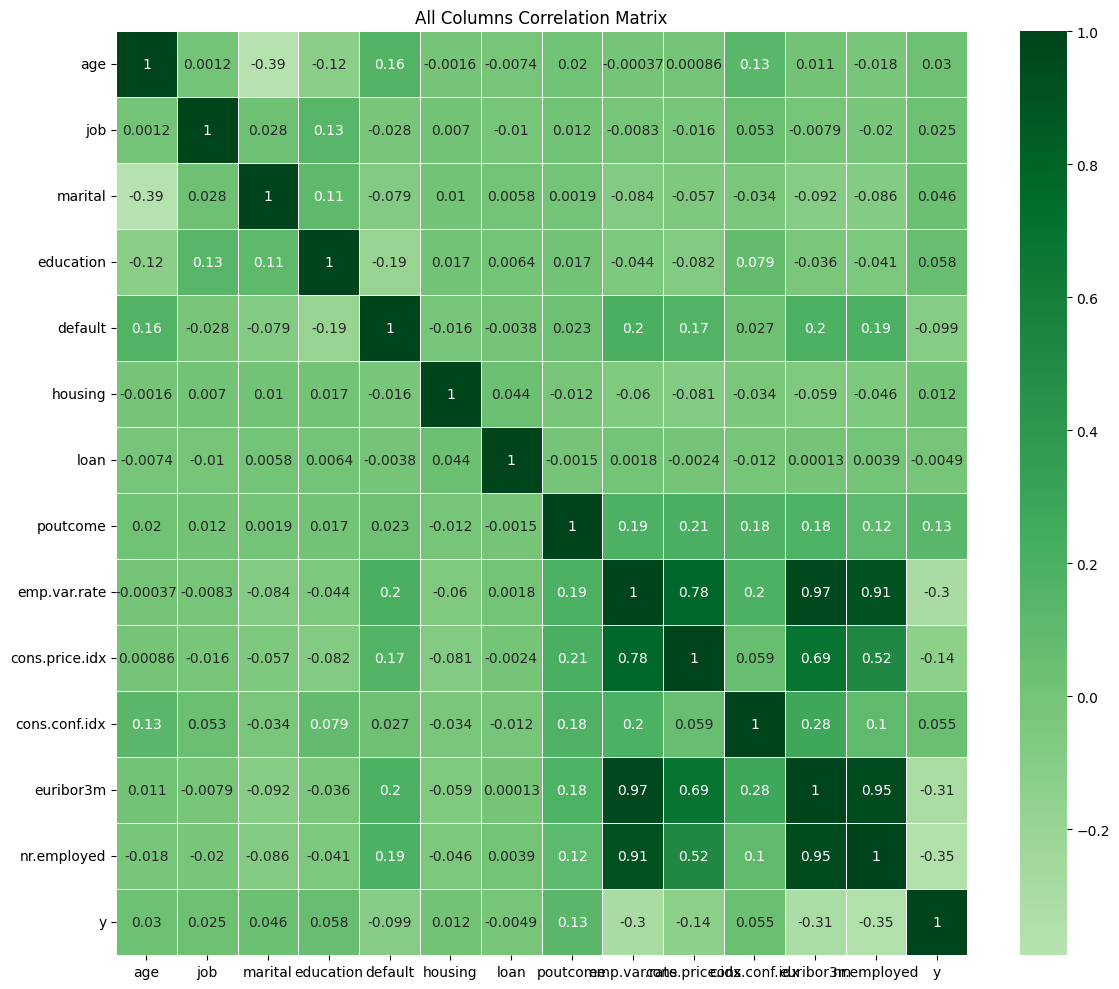

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 2) 상관행렬 계산
corr_matrix = df_1.corr()

# 3) 히트맵 시각화
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix,
            cmap='Greens',
            annot=True,
            center=0,
            linewidths=0.5)       # 셀 경계선
plt.title('All Columns Correlation Matrix')
plt.xticks(rotation=360)
plt.yticks(rotation=360)
plt.tight_layout()
plt.show()

상관관계가 강한 상위 5개 데이터들 목록이다.

 - nr.employed(고용자 수)
 - euribor3m(유로존 금리)
 - euribor3m(소비자 물가지수)
 - emp.var.rate(고용 변화율)
 - cons.conf.idx(소비자 신뢰지수) 양의 상관관계를 띄고 다른 변수들에 비해 약하다.

5개 데이터는 경제 관련 지표들이고 서로 영향을 주는 것을 알 수 있다.

하지만 소비자 신뢰지수는 사람들이 느끼는 정도를 나타내는 수치이므로 객관적인 지표가 아니기에 상관관계가 높지 않는 듯 하다.

## 로지스틱 회귀분석

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import numpy as np

# 변수 선언
X = df_1.drop('y', axis=1)
y = df_1['y']

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 모델 학습
model = LogisticRegression()
model.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
# 예측치 시각화 준비
prob = pd.DataFrame(model.predict_proba(X_train))   # 예금을 들 확률
cs = model.decision_function(X_train)

# 데이터 병합
result_df = pd.concat([prob, pd.DataFrame(cs)], axis=1)
result_df.columns=['Not 1', '1', 'decision_function']

# 데이터 프레임 정리
result_df.sort_values(['decision_function'], inplace=True)
result_df.reset_index(inplace=True, drop=True)

result_df

,Not 1,1,decision_function
0,0.976478,0.023522,-3.726019
1,0.976478,0.023522,-3.726019
2,0.976408,0.023592,-3.722955
3,0.976350,0.023650,-3.720450
4,0.976080,0.023920,-3.708839
...,...,...,...
28826,0.437357,0.562643,0.251897
28827,0.436805,0.563195,0.254140
28828,0.436688,0.563312,0.254616
28829,0.435053,0.564947,0.261264


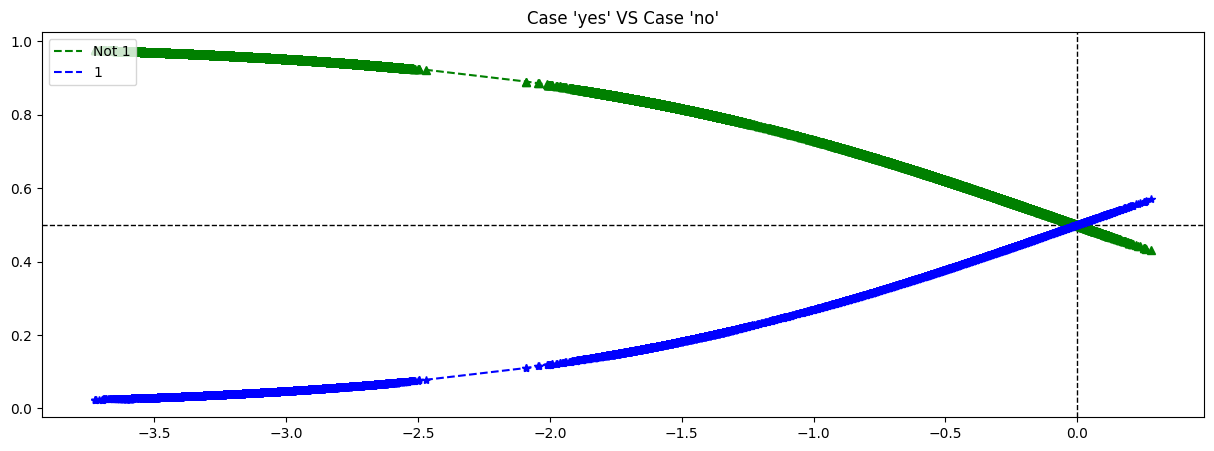

In [ ]:
# 시각화
plt.figure(figsize=(15,5))

plt.axhline(y=0.5, linestyle='--', color='black', linewidth=1)
plt.axvline(x=0, linestyle='--', color='black', linewidth=1)

plt.plot(result_df['decision_function'], result_df['Not 1'], 'g--', label='Not 1')
plt.plot(result_df['decision_function'], result_df['Not 1'], 'g^')
plt.plot(result_df['decision_function'], result_df['1'], 'b--', label='1')
plt.plot(result_df['decision_function'], result_df['1'], 'b*')

plt.xlabel
plt.ylabel

plt.title("Case 'yes' VS Case 'no'")
plt.legend(loc='upper left')
plt.show()

대출을 받지 않는 케이스에 대한 것은 많지만 반대의 경우가 제대로 예측 되지 않는 것 같다.

통계점수도 혼동행렬을 통해 알아보자.

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

pred = model.predict(X_test)

test_cm = confusion_matrix(y_test, pred)
test_acc = accuracy_score(y_test, pred)
test_prc = precision_score(y_test, pred)
test_rcll = recall_score(y_test, pred)
test_f1 = f1_score(y_test, pred)

print('Confusion Metrix')
print(test_cm)
print('/n')
print("정확도\t{}%".format(round(test_acc*100,2)))
print("정밀도\t{}%".format(round(test_prc*100,2)))
print("재현율\t{}%".format(round(test_rcll*100,2)))
print("F1_Score\t{}%".format(round(test_f1*100,2)))

Confusion Metrix
[[10914    54]
 [ 1351    38]]
/n
정확도	88.63%
정밀도	41.3%
재현율	2.74%
F1_Score	5.13%


ROC 커브

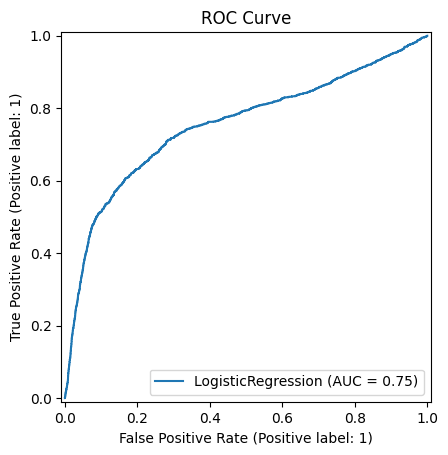

In [ ]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.title("ROC Curve")
plt.show()

### F1_Score: 5.13%

Recall: 2.74%

Precision: 41.3%

Accuracy: 88.63%

AUC: 0.75

## Decision Tree

의사결정 나무도 한번 사용해보자

In [ ]:
from sklearn.tree import DecisionTreeClassifier
# 변수 선언
X = df_1.drop('y', axis=1)
y = df_1['y']

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 모델 학습
model = DecisionTreeClassifier(max_depth=5)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5)

In [ ]:
pred = model.predict(X_test)

test_cm = confusion_matrix(y_test, pred)
test_acc = accuracy_score(y_test, pred)
test_prc = precision_score(y_test, pred)
test_rcll = recall_score(y_test, pred)
test_f1 = f1_score(y_test, pred)

print('Confusion Metrix')
print(test_cm)
print('/n')
print("정확도\t{}%".format(round(test_acc*100,2)))
print("정밀도\t{}%".format(round(test_prc*100,2)))
print("재현율\t{}%".format(round(test_rcll*100,2)))
print("F1_Score\t{}%".format(round(test_f1*100,2)))

Confusion Metrix
[[10832   136]
 [ 1106   283]]
/n
정확도	89.95%
정밀도	67.54%
재현율	20.37%
F1_Score	31.31%


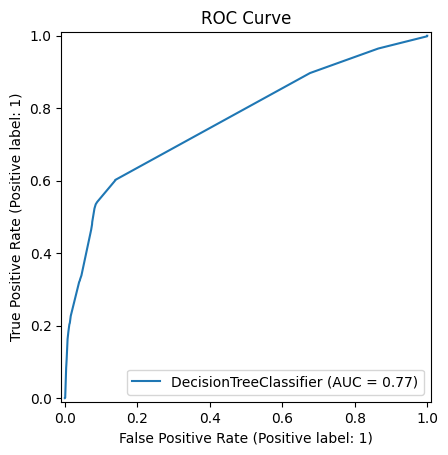

In [ ]:
RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.title("ROC Curve")
plt.show()

트리 시각화

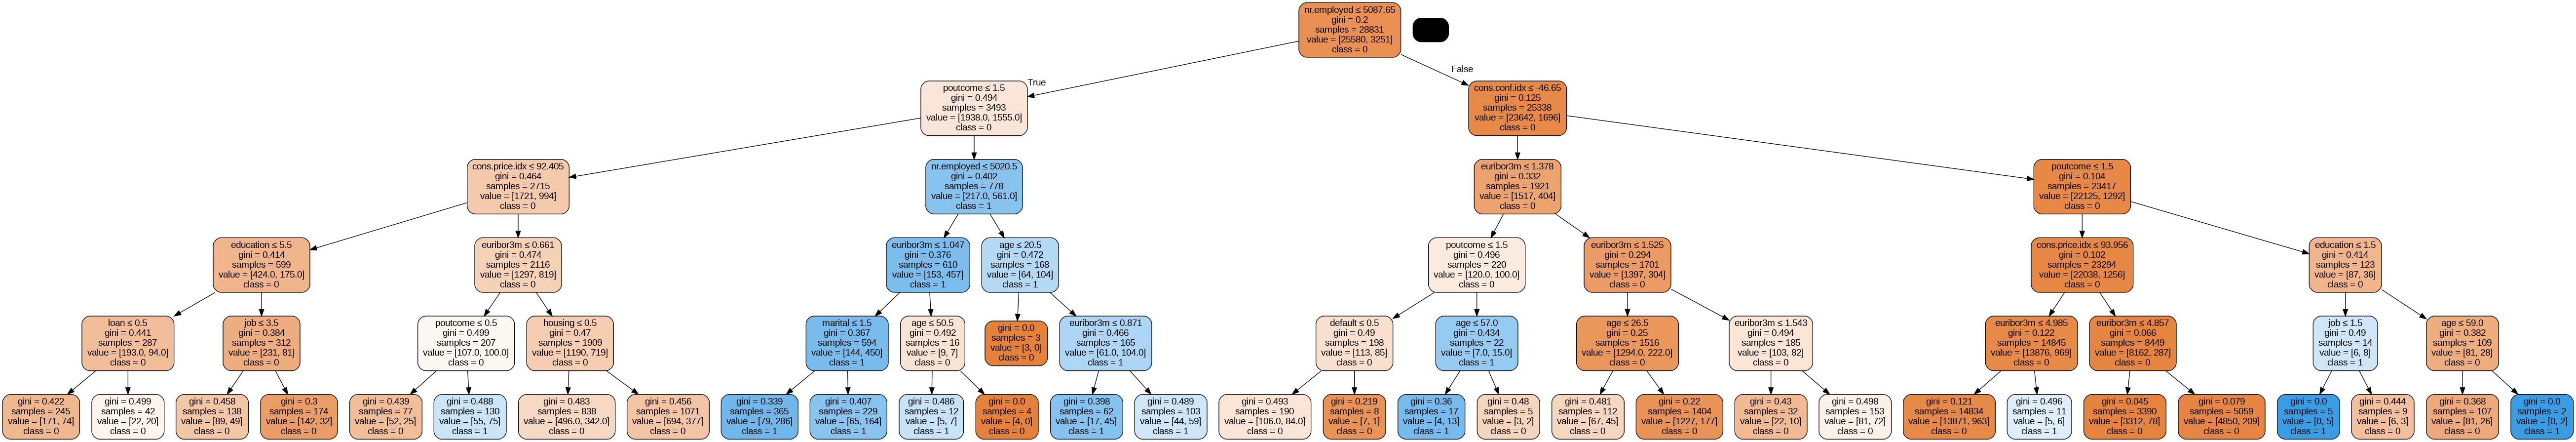

In [ ]:
feature_names = X.columns
target_names = np.array(['0', '1'])

import pydot
import pydotplus
import graphviz
from sklearn.tree import export_graphviz
dt_dot_data = export_graphviz(model, feature_names=feature_names,
                              class_names = target_names,
                              filled=True, rounded=True,
                              special_characters=True)
dt_graph = pydotplus.graph_from_dot_data(dt_dot_data)

from IPython.display import Image
Image(dt_graph.create_png())

### F1_Score: 31.31%
정확도	89.95%

정밀도	67.54%

재현율	20.37%

트리모델이 조금더 나은 양상은 보였으나 직감이 아닌 전체데이터를 보고 중요도를 파악하고 트리기반 다른 모델을 사용해 보겠다.

# 전체 데이터활용 분석

In [ ]:
df_2 = df.copy()
df_2

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,1
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,0
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,0
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,1


In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

columns_categorical
for ob in columns_categorical:
    df_2[ob] = encoder.fit_transform(df_2[ob])
df_2.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,3,1,0,0,0,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
1,57,7,1,3,1,0,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
2,37,7,1,3,0,2,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
3,40,0,1,1,0,0,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
4,56,7,1,3,0,0,2,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0


## Decision Tree 2차 학습

In [ ]:
from sklearn.tree import DecisionTreeClassifier
# 변수 선언
X = df_2.drop('y', axis=1)
y = df_2['y']

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 모델 학습
model = DecisionTreeClassifier(max_depth=5)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5)

In [ ]:
pred = model.predict(X_test)

test_cm = confusion_matrix(y_test, pred)
test_acc = accuracy_score(y_test, pred)
test_prc = precision_score(y_test, pred)
test_rcll = recall_score(y_test, pred)
test_f1 = f1_score(y_test, pred)

print('Confusion Metrix')
print(test_cm)
print('/n')
print("정확도\t{}%".format(round(test_acc*100,2)))
print("정밀도\t{}%".format(round(test_prc*100,2)))
print("재현율\t{}%".format(round(test_rcll*100,2)))
print("F1_Score\t{}%".format(round(test_f1*100,2)))

Confusion Metrix
[[10595   373]
 [  661   728]]
/n
정확도	91.63%
정밀도	66.12%
재현율	52.41%
F1_Score	58.47%


### 변수중요도 탐색

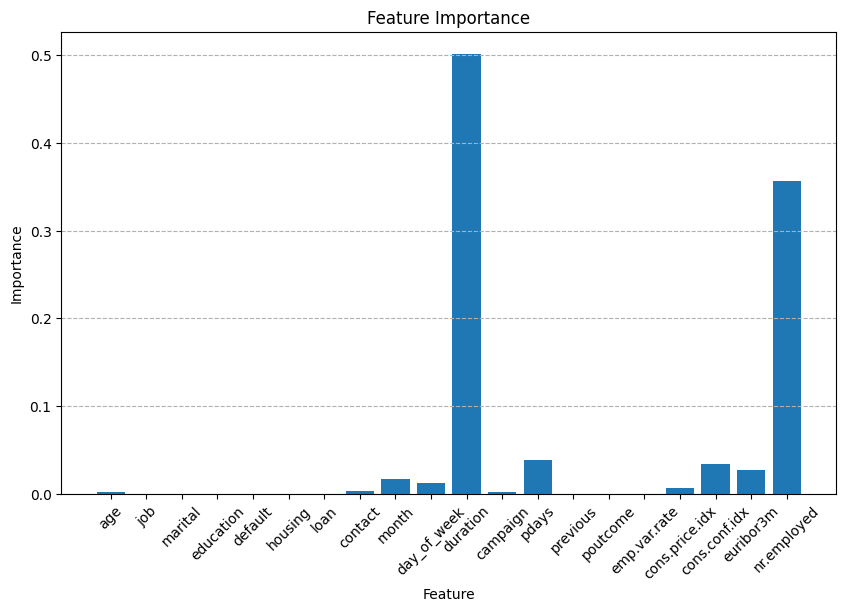

In [ ]:
importances = model.feature_importances_
column_nm = pd.DataFrame(X.columns)
feature_importances = pd.concat([column_nm, pd.DataFrame(importances)], axis=1)
feature_importances.columns = ['feature_nm', 'importances']
# 중요도 시각화 #1

plt.figure(figsize=(10,6))
plt.bar(feature_importances['feature_nm'], feature_importances['importances'])
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importance")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--')
plt.show()

age, marital, contact, month, day_of_week, duration, campaign, pdays, cons.price.idx, cons.conf.idx, euribor3m, nr.employed가 중요도가 있었고 나머지는 미미한 것 같다. 특히 duration, nr.employed이 두 칼럼의 중요도가 높았다.

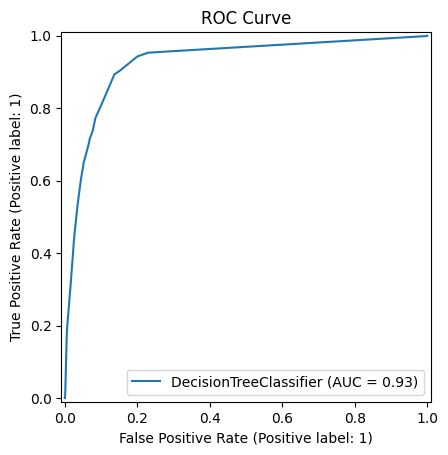

In [ ]:
RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.title("ROC Curve")
plt.show()

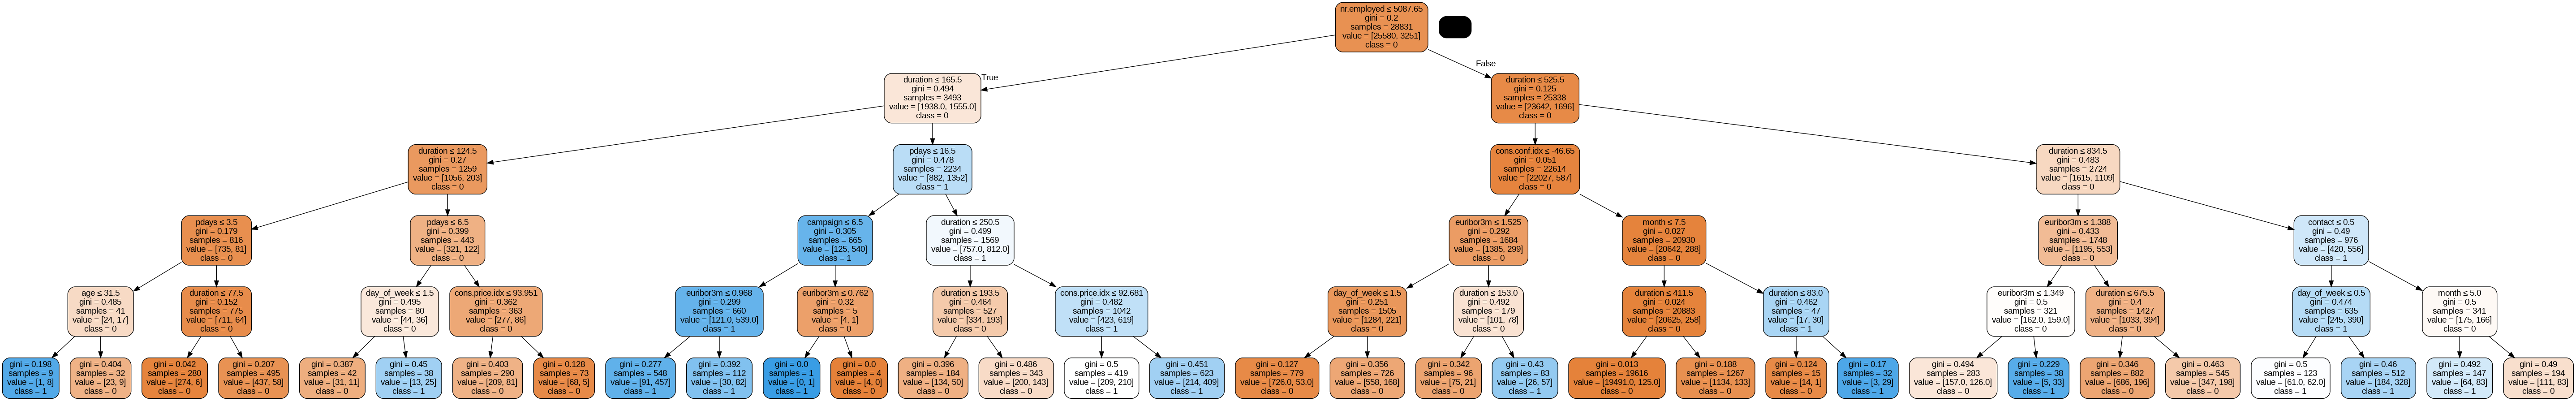

In [ ]:
feature_names = X.columns
target_names = np.array(['0', '1'])

import pydot
import pydotplus
import graphviz
from sklearn.tree import export_graphviz
dt_dot_data = export_graphviz(model, feature_names=feature_names,
                              class_names = target_names,
                              filled=True, rounded=True,
                              special_characters=True)
dt_graph = pydotplus.graph_from_dot_data(dt_dot_data)

from IPython.display import Image
Image(dt_graph.create_png())

### F1_Score: 58.47%
정확도	91.63%

정밀도	66.12%

재현율	52.41%

데이터 관련 문서에서 duration은 실제 예측 모델에서는 제외해야 한다 했으므로 제외하고 한번 더 해보겠다.

In [ ]:
df_drop_dur = df_2.copy()

In [ ]:
df_drop_dur = df_drop_dur.drop('duration', axis=1)
df_drop_dur.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,3,1,0,0,0,0,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
1,57,7,1,3,1,0,0,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
2,37,7,1,3,0,2,0,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
3,40,0,1,1,0,0,0,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
4,56,7,1,3,0,0,2,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0


## Decision Tree 3차 학습

In [ ]:
from sklearn.tree import DecisionTreeClassifier
# 변수 선언
X = df_drop_dur.drop('y', axis=1)
y = df_drop_dur['y']

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 모델 학습
model = DecisionTreeClassifier(max_depth=5)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5)

In [ ]:
pred = model.predict(X_test)

test_cm = confusion_matrix(y_test, pred)
test_acc = accuracy_score(y_test, pred)
test_prc = precision_score(y_test, pred)
test_rcll = recall_score(y_test, pred)
test_f1 = f1_score(y_test, pred)

print('Confusion Metrix')
print(test_cm)
print('/n')
print("정확도\t{}%".format(round(test_acc*100,2)))
print("정밀도\t{}%".format(round(test_prc*100,2)))
print("재현율\t{}%".format(round(test_rcll*100,2)))
print("F1_Score\t{}%".format(round(test_f1*100,2)))

Confusion Metrix
[[10763   205]
 [ 1032   357]]
/n
정확도	89.99%
정밀도	63.52%
재현율	25.7%
F1_Score	36.6%


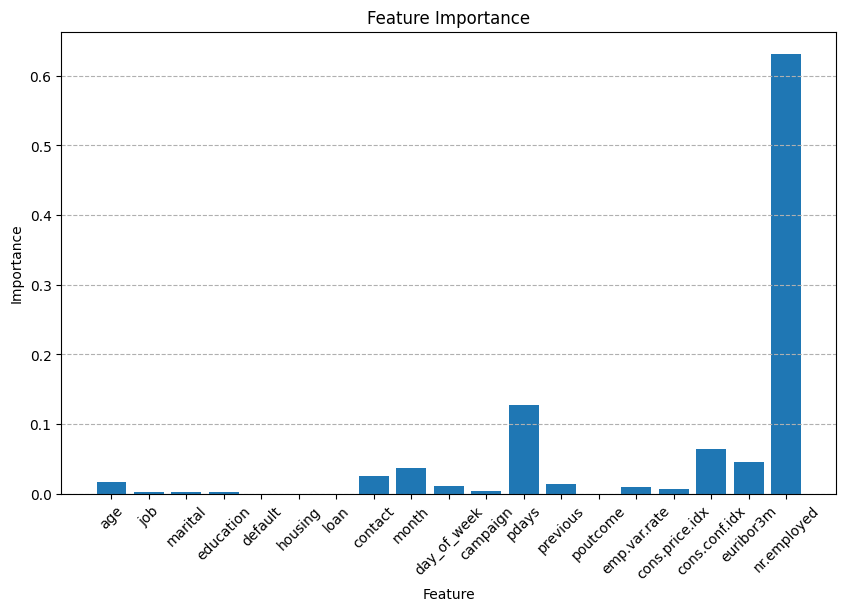

In [ ]:
importances = model.feature_importances_
column_nm = pd.DataFrame(X.columns)
feature_importances = pd.concat([column_nm, pd.DataFrame(importances)], axis=1)
feature_importances.columns = ['feature_nm', 'importances']
# 중요도 시각화 #1

plt.figure(figsize=(10,6))
plt.bar(feature_importances['feature_nm'], feature_importances['importances'])
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importance")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--')
plt.show()

다른 변수들의 중요도가 더 올라갔다!

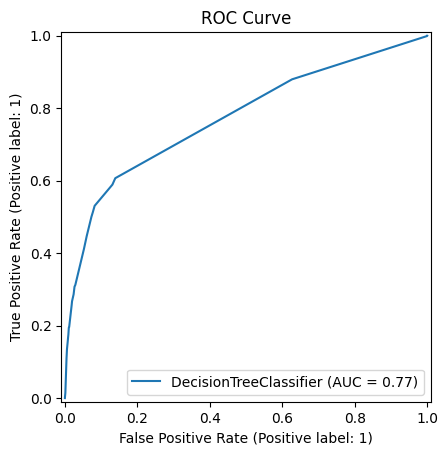

In [ ]:
RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.title("ROC Curve")
plt.show()

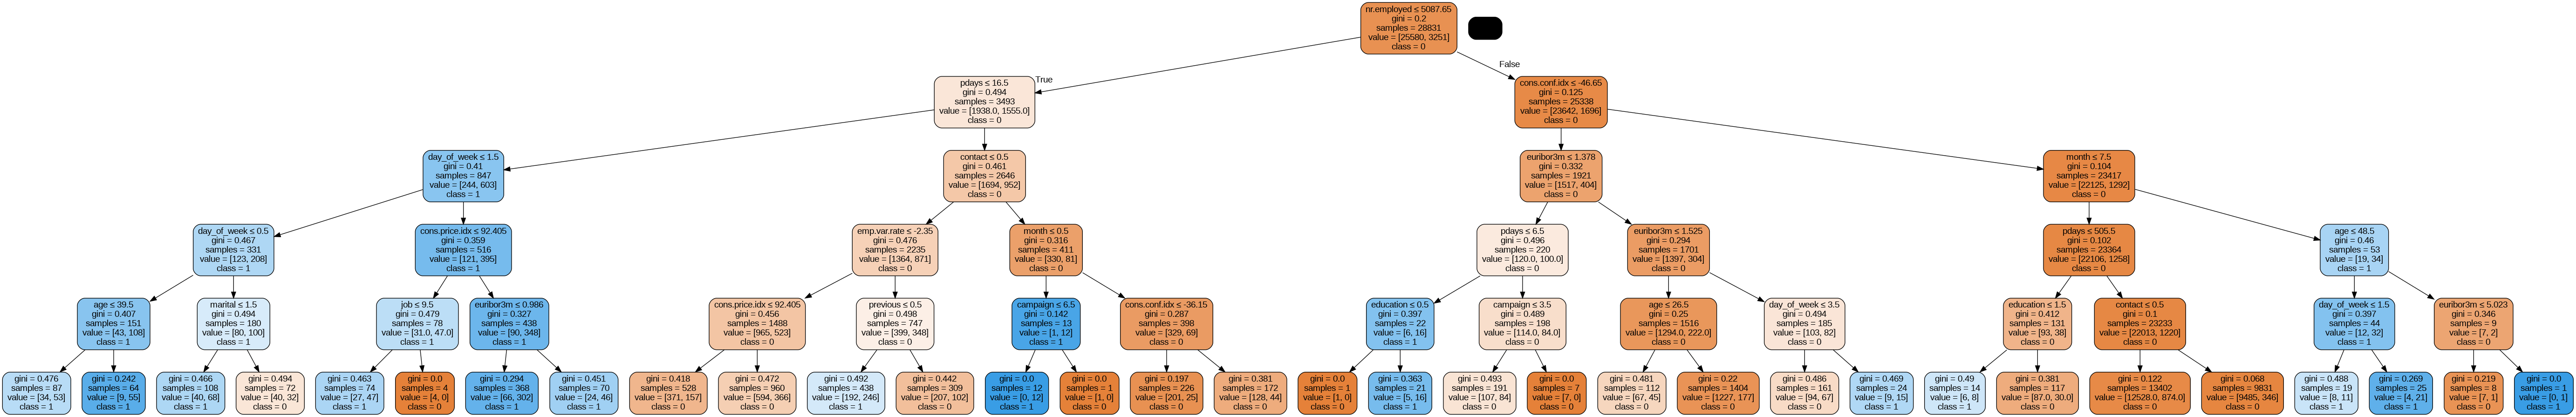

In [ ]:
feature_names = X.columns
target_names = np.array(['0', '1'])

import pydot
import pydotplus
import graphviz
from sklearn.tree import export_graphviz
dt_dot_data = export_graphviz(model, feature_names=feature_names,
                              class_names = target_names,
                              filled=True, rounded=True,
                              special_characters=True)
dt_graph = pydotplus.graph_from_dot_data(dt_dot_data)

from IPython.display import Image
Image(dt_graph.create_png())


### F1_Score: 36.58%
정확도	89.98%

정밀도	63.41%

재현율	25.7%

점수는 내려갔으나, 다른 데이터의 의존도가 올라갔다.

## 특성 공학

데이터를 둘러보니 데이터 수정을 좀 할 필요 있는 데이터 들이 있다.
 - campaign: 0(연락안함), 1(연락함: 연락한것중에서도 연락을 1번햇냐 여러변햇냐로 나눌 수도 있음)
 - age: 14년도 당시 평균수명 확인필요, 100살 넘는 인간이 있을까?

 (https://countryeconomy.com/demography/life-expectancy/portugal?year=2012&utm_source=chatgpt.com)
 - pdays: 재연락이 있냐 없냐로 나눠도 될것같음.
 - previous: 이전 연락이 있냐 없냐로 나눠도 될것같음.

추가로 탐색 할 필요가 있는 데이터 들이다.

🔸 사회·경제 지표 (전국 단위)
1.	emp.var.rate: 고용 변화율 (분기별 지표)
2.	cons.price.idx: 소비자물가지수 (월간 지표)
3.	cons.conf.idx: 소비자 신뢰지수 (월간 지표)
4.	euribor3m: 유로존 3개월 금리 (일일 지표)
5.	nr.employed: 고용자 수 (분기별 지표)


In [ ]:
df_3 = df.copy()
df_3

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,1
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,0
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,0
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,1


### 생각한 파생변수 목록
 1. 일이 있는사람과 없는사람.
 2. 독신 VS 기혼
 3. 주담대 + 개인대출의 여부
 4. 회사에서 전화를 한번이라도 한적이 있나요?(pdays + previous + poutcome)
  - pdays제외하고 변수중요도가 많이 떨어진다.

In [ ]:
df_3['previous'].unique()

array([0, 1, 2, 3, 4, 5, 6, 7])

In [ ]:
df_3['pdays'].unique()

array([999,   6,   4,   3,   5,   1,   0,  10,   7,   8,   9,  11,   2,
        12,  13,  14,  15,  16,  21,  17,  18,  22,  25,  26,  19,  27,
        20])

In [ ]:
df_3['poutcome'].unique()

array(['nonexistent', 'failure', 'success'], dtype=object)

In [ ]:
df_3['previous_bi'] = df_3['previous'].apply(lambda x: 0 if x == 0 else 1)    # 전화를 1번이라도 한적이 있다면 1 아니면 0

In [ ]:
df_3['pdays_bi'] = df_3['pdays'].apply(lambda x: 0 if x == 999 else 1)    # 전화를 1번이라도 한적이 있다면 1 아니면 0

In [ ]:
df_3['poutcome_bi'] = df_3['poutcome'].apply(lambda x: 0 if x == 'nonexistent' else 1)    # 전화를 1번이라도 한적이 있다면 1 아니면 0

In [ ]:
df_3

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,previous_bi,pdays_bi,poutcome_bi
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0,0,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0,0,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0,0,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0,0,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,1,0,0,0
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,0,0,0,0
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,0,0,0,0
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,1,0,0,0


In [ ]:
df_3['newBi'] = 1  # 기본값을 1로 설정
df_3.loc[(df_3['poutcome_bi'] == 0) & (df_3['pdays_bi'] == 0) & (df_3['previous_bi'] == 0), 'newBi'] = 0
df_3

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,previous_bi,pdays_bi,poutcome_bi,newBi
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1.1,93.994,-36.4,4.857,5191.0,0,0,0,0,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1.1,93.994,-36.4,4.857,5191.0,0,0,0,0,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1.1,93.994,-36.4,4.857,5191.0,0,0,0,0,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1.1,93.994,-36.4,4.857,5191.0,0,0,0,0,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1.1,93.994,-36.4,4.857,5191.0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,-1.1,94.767,-50.8,1.028,4963.6,1,0,0,0,0
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,-1.1,94.767,-50.8,1.028,4963.6,0,0,0,0,0
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,-1.1,94.767,-50.8,1.028,4963.6,0,0,0,0,0
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,-1.1,94.767,-50.8,1.028,4963.6,1,0,0,0,0


In [ ]:
df_3['newBi'].value_counts()

,count
newBi,
0,35563
1,5625


은행과 전화를 1번도 안해본 사람을 0 1번이라도 해봤다 하면 1로 분류를 했다.

In [ ]:
df_3['marital'].value_counts()

,count
marital,
married,24928
single,11568
divorced,4612
unknown,80


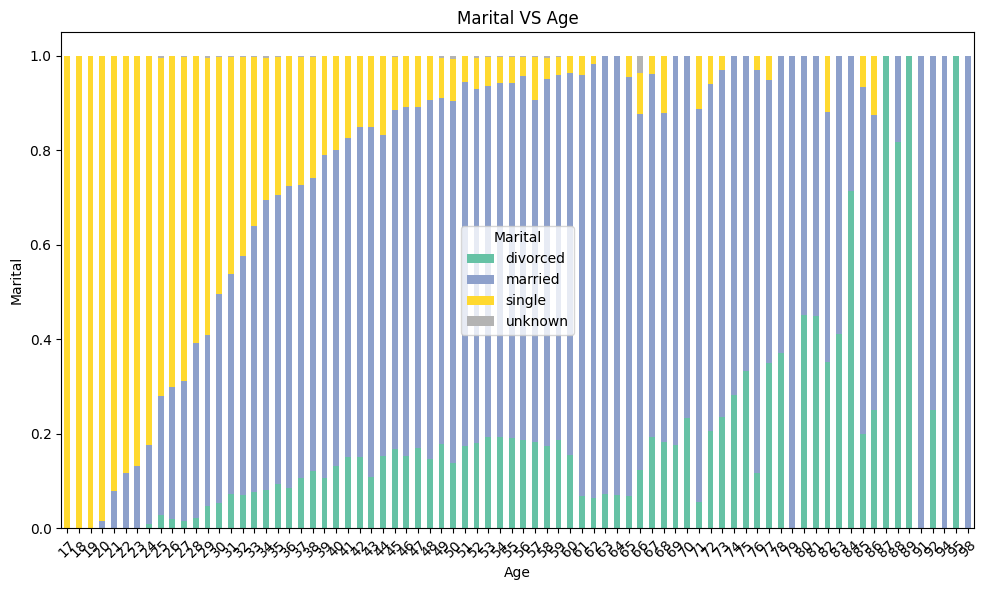

In [ ]:
ct = pd.crosstab(df_3['age'], df_3['marital'], normalize='index')

ct.plot(kind='bar', stacked=True, figsize=(10,6), colormap='Set2')
plt.title('Marital VS Age')
plt.xlabel('Age')
plt.ylabel('Marital')
plt.legend(title='Marital')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

unknown는 고의로 입력을 안했을 수 있기에 single로 보는것이 좋을 것 같다.

In [ ]:
# 현재 기준 독신인지 아닌지
df_3['is_married'] = df_3['marital'].apply(lambda x: 1 if x == 'married' else 0)

In [ ]:
df_3['is_married'].value_counts()

,count
is_married,
1,24928
0,16260


In [ ]:
# 현재 고정 수입이 있는 사람과 아닌사람
df_3['earn_bill'] = df_3['job'].apply(lambda x: 0 if x == 'housemaid' or x == 'retired' or x == 'unknown' or x == 'student'else 1)

In [ ]:
df_3['earn_bill'].value_counts()

,count
earn_bill,
1,37203
0,3985


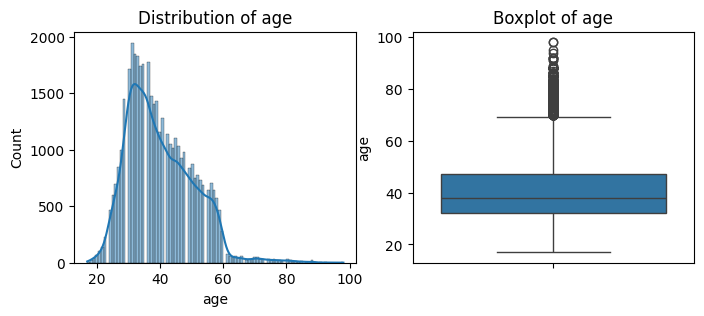

In [ ]:
plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
sns.histplot(df['age'], kde=True)
plt.title('Distribution of age')
plt.subplot(1, 2, 2)
sns.boxplot(y=df['age'])
plt.title('Boxplot of age')
plt.show()

In [ ]:
print(max(df['age']), min(df['age']))

98 17


17세와 98세가 최대 최소 연령이다. 로그변환을 통해 분포를 바꿔보자

/tmp/ipython-input-59-3786758722.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['age'], ax=axes[0][0])
/tmp/ipython-input-59-3786758722.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(np.log(df['age']), ax=axes[1][0])


((array([-4.1471943 , -3.9393642 , -3.82597553, ...,  3.82597553,
          3.9393642 ,  4.1471943 ]),
  array([2.89037176, 2.89037176, 2.89037176, ..., 4.56434819, 4.59511985,
         4.59511985])),
 (np.float64(0.24638769377268552),
  np.float64(3.6832487939083856),
  np.float64(0.9956676153640864)))

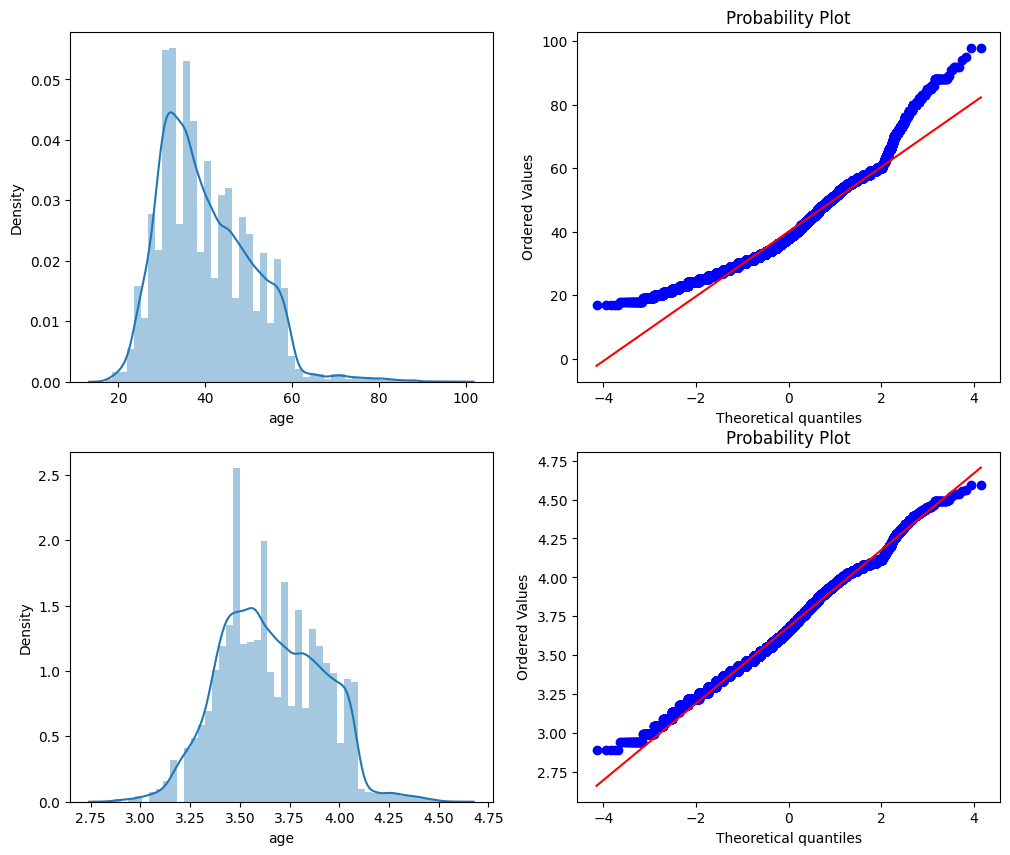

In [ ]:
from scipy import stats
# count 값의 데이터 분포 파악
figure, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.distplot(df['age'], ax=axes[0][0])
stats.probplot(df['age'], dist='norm', fit=True, plot=axes[0][1])
sns.distplot(np.log(df['age']), ax=axes[1][0])
stats.probplot(np.log1p(df['age']), dist='norm', fit=True, plot=axes[1][1])

로그변환 시 정규분포에 가까워 진 것을 확인 할 수 있었다. 모델 학습 시 참고하자.

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for ob in columns_categorical:
    df_3[ob] = encoder.fit_transform(df_3[ob])

In [ ]:
df_3 = df_3.drop('duration', axis=1)

## Decision Tree 4차 학습(채택)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
# 변수 선언
X = df_3.drop('y', axis=1)
y = df_3['y']

# 로그 변환
X['age'] = np.log(X['age'])

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 모델 학습
model = DecisionTreeClassifier(max_depth=5)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5)

In [ ]:
# 지수 변환
X_test['age'] = np.exp(X_test['age'])
X_test['age']

,age
32884,57.0
3169,55.0
32206,33.0
9403,36.0
14020,27.0
...,...
15908,46.0
28222,38.0
14194,26.0
19764,51.0


In [ ]:
pred = model.predict(X_test)

test_cm = confusion_matrix(y_test, pred)
test_acc = accuracy_score(y_test, pred)
test_prc = precision_score(y_test, pred)
test_rcll = recall_score(y_test, pred)
test_f1 = f1_score(y_test, pred)

print('Confusion Metrix')
print(test_cm)
print('/n')
print("정확도\t{}%".format(round(test_acc*100,2)))
print("정밀도\t{}%".format(round(test_prc*100,2)))
print("재현율\t{}%".format(round(test_rcll*100,2)))
print("F1_Score\t{}%".format(round(test_f1*100,2)))

Confusion Metrix
[[10767   201]
 [ 1038   351]]
/n
정확도	89.97%
정밀도	63.59%
재현율	25.27%
F1_Score	36.17%


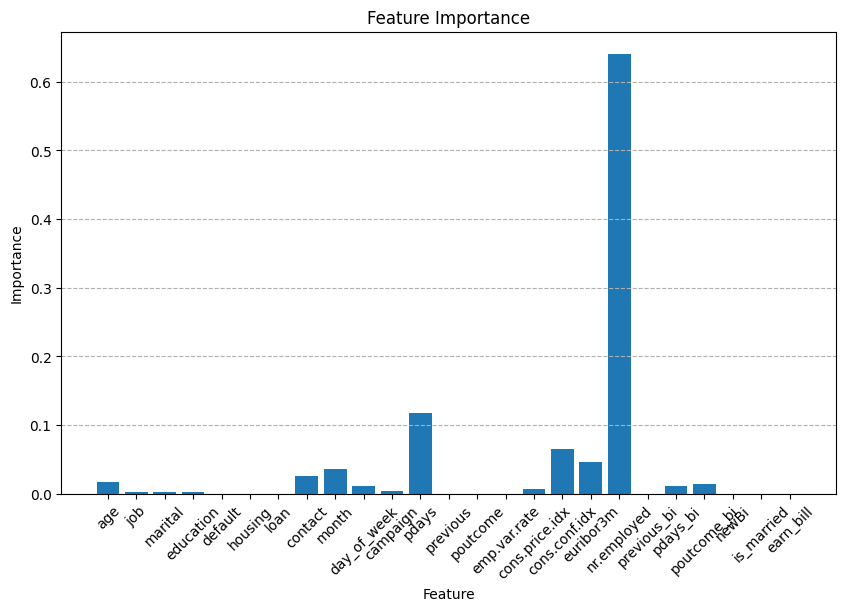

In [ ]:
importances = model.feature_importances_
column_nm = pd.DataFrame(X.columns)
feature_importances = pd.concat([column_nm, pd.DataFrame(importances)], axis=1)
feature_importances.columns = ['feature_nm', 'importances']
# 중요도 시각화 #1

plt.figure(figsize=(10,6))
plt.bar(feature_importances['feature_nm'], feature_importances['importances'])
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importance")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--')
plt.show()

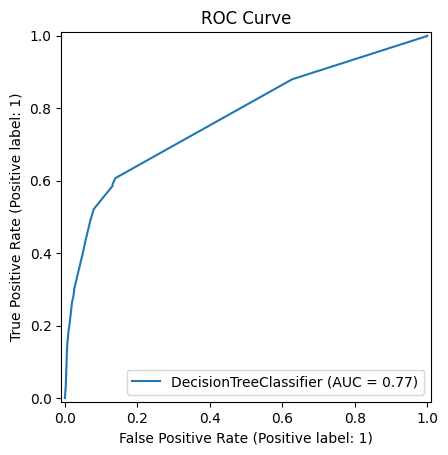

In [ ]:
RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.title("ROC Curve")
plt.show()

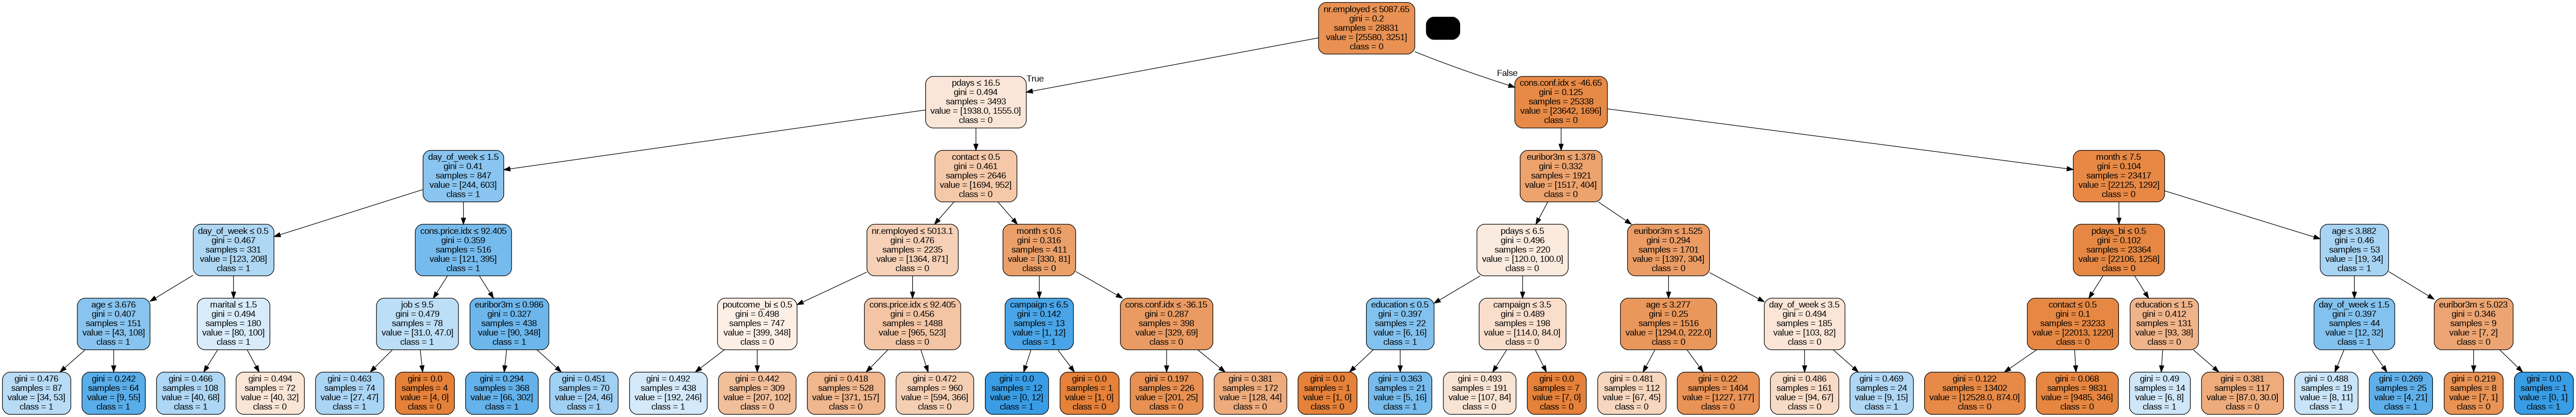

In [ ]:
feature_names = X.columns
target_names = np.array(['0', '1'])

import pydot
import pydotplus
import graphviz
from sklearn.tree import export_graphviz
dt_dot_data = export_graphviz(model, feature_names=feature_names,
                              class_names = target_names,
                              filled=True, rounded=True,
                              special_characters=True)
dt_graph = pydotplus.graph_from_dot_data(dt_dot_data)

from IPython.display import Image
Image(dt_graph.create_png())

현재 코드에서 파생변수와 내용이 겹치는 칼럼을 한번 지워보겠다.

### F1_Score: 35.24%
정확도	89.92%

정밀도	63.36%

재현율	24.41%



## Decision Tree 5차 학습

In [ ]:
df_4 = df_3.copy()
df_4

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,cons.conf.idx,euribor3m,nr.employed,y,previous_bi,pdays_bi,poutcome_bi,newBi,is_married,earn_bill
0,56,3,1,0,0,0,0,1,6,1,...,-36.4,4.857,5191.0,0,0,0,0,0,1,0
1,57,7,1,3,1,0,0,1,6,1,...,-36.4,4.857,5191.0,0,0,0,0,0,1,1
2,37,7,1,3,0,2,0,1,6,1,...,-36.4,4.857,5191.0,0,0,0,0,0,1,1
3,40,0,1,1,0,0,0,1,6,1,...,-36.4,4.857,5191.0,0,0,0,0,0,1,1
4,56,7,1,3,0,0,2,1,6,1,...,-36.4,4.857,5191.0,0,0,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,5,1,5,0,2,0,0,7,0,...,-50.8,1.028,4963.6,1,0,0,0,0,1,0
41184,46,1,1,5,0,0,0,0,7,0,...,-50.8,1.028,4963.6,0,0,0,0,0,1,1
41185,56,5,1,6,0,2,0,0,7,0,...,-50.8,1.028,4963.6,0,0,0,0,0,1,0
41186,44,9,1,5,0,0,0,0,7,0,...,-50.8,1.028,4963.6,1,0,0,0,0,1,1


In [ ]:
drop = ['job', 'marital', 'previous', 'poutcome']
df_4 = df_4.drop(drop, axis=1)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
# 변수 선언
X = df_4.drop('y', axis=1)
y = df_4['y']

# 로그 변환
X['age'] = np.log(X['age'])

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 모델 학습
model = DecisionTreeClassifier(max_depth=5)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5)

In [ ]:
# 지수 변환
X_test['age'] = np.exp(X_test['age'])
X_test['age']

,age
32884,57.0
3169,55.0
32206,33.0
9403,36.0
14020,27.0
...,...
15908,46.0
28222,38.0
14194,26.0
19764,51.0


In [ ]:
pred = model.predict(X_test)

test_cm = confusion_matrix(y_test, pred)
test_acc = accuracy_score(y_test, pred)
test_prc = precision_score(y_test, pred)
test_rcll = recall_score(y_test, pred)
test_f1 = f1_score(y_test, pred)

print('Confusion Metrix')
print(test_cm)
print('/n')
print("정확도\t{}%".format(round(test_acc*100,2)))
print("정밀도\t{}%".format(round(test_prc*100,2)))
print("재현율\t{}%".format(round(test_rcll*100,2)))
print("F1_Score\t{}%".format(round(test_f1*100,2)))

Confusion Metrix
[[10759   209]
 [ 1037   352]]
/n
정확도	89.92%
정밀도	62.75%
재현율	25.34%
F1_Score	36.1%


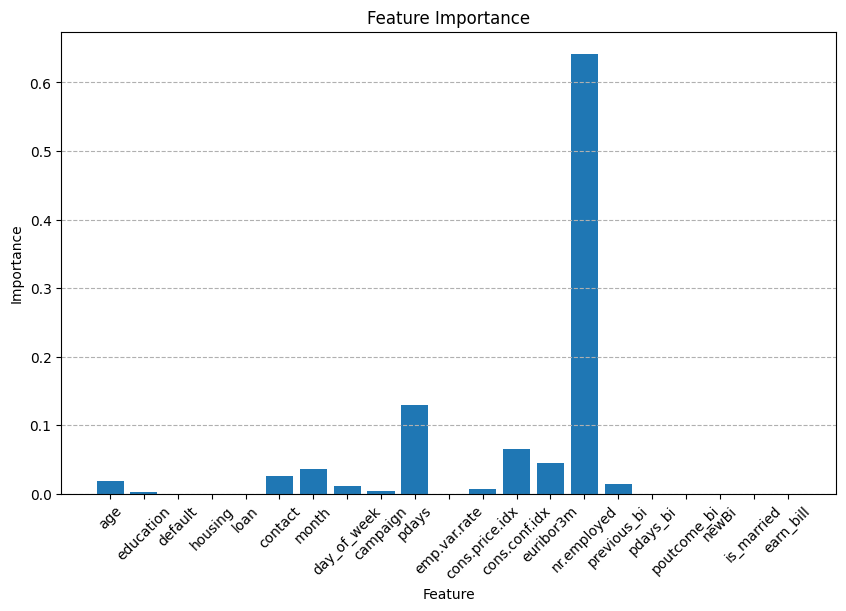

In [ ]:
importances = model.feature_importances_
column_nm = pd.DataFrame(X.columns)
feature_importances = pd.concat([column_nm, pd.DataFrame(importances)], axis=1)
feature_importances.columns = ['feature_nm', 'importances']

# 중요도 시각화 #1

plt.figure(figsize=(10,6))
plt.bar(feature_importances['feature_nm'], feature_importances['importances'])
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importance")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--')
plt.show()

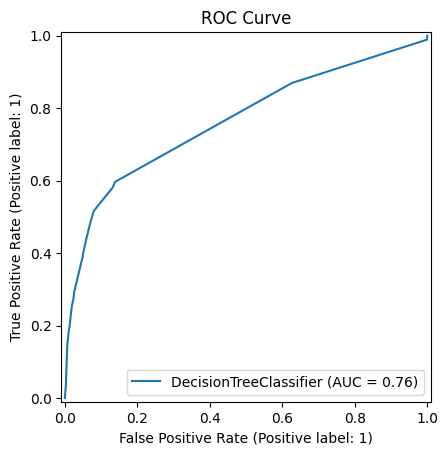

In [ ]:
RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.title("ROC Curve")
plt.show()

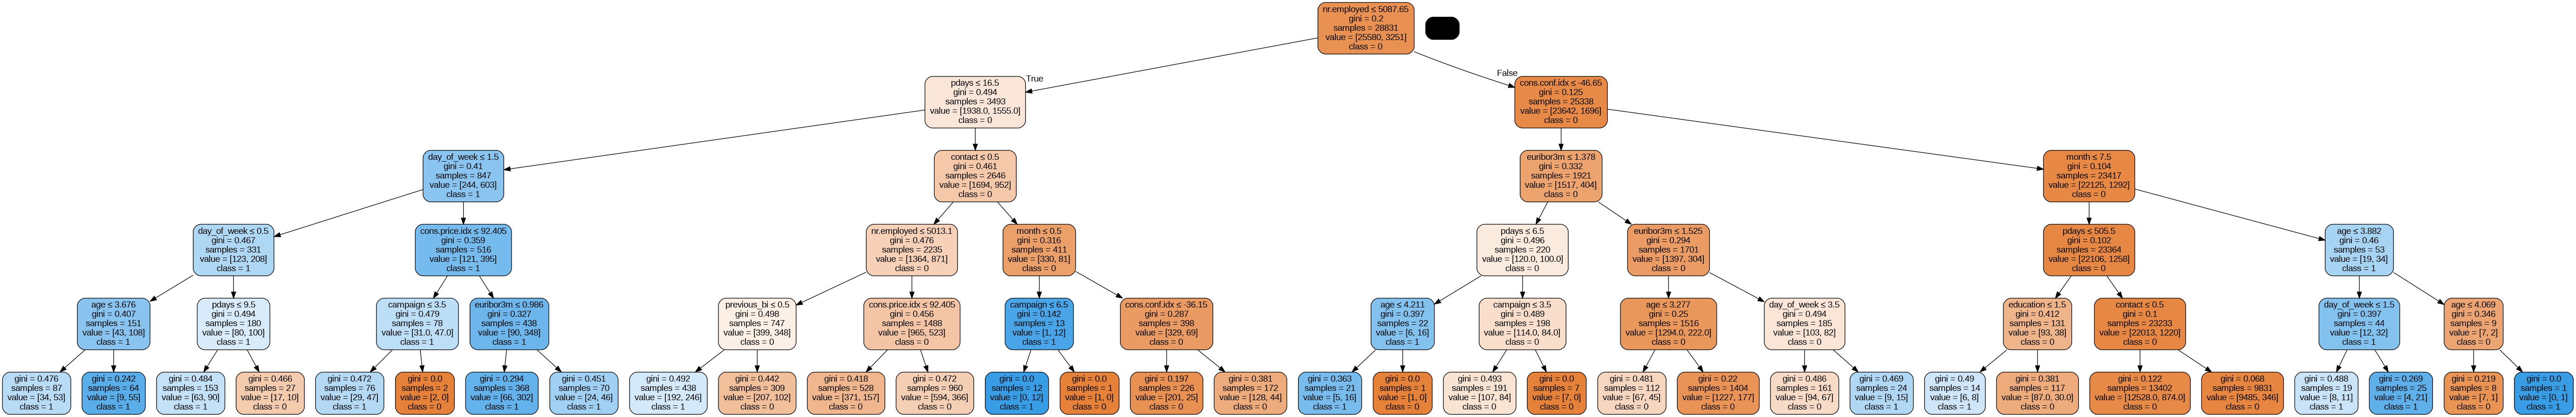

In [ ]:
feature_names = X.columns
target_names = np.array(['0', '1'])

import pydot
import pydotplus
import graphviz
from sklearn.tree import export_graphviz
dt_dot_data = export_graphviz(model, feature_names=feature_names,
                              class_names = target_names,
                              filled=True, rounded=True,
                              special_characters=True)
dt_graph = pydotplus.graph_from_dot_data(dt_dot_data)

from IPython.display import Image
Image(dt_graph.create_png())

### F1_Score: 36.52%
정확도	89.96%

정밀도	63.07%

재현율	25.7%

중요도가 낮고 파생변수와 겹치는 컬럼을 제거해도 점수는 여전히 같았다.

좀 더 발전된 모델들을 사용할 필요가 있다.

## Decision Tree 6차 학습(하이퍼 파라미터 조정)

k-fold 교차검증을 통해 최적의 깊이와 리프, 노드를 찾자.

__Precision__을 높혀보자

In [ ]:
df_6 = df_3.copy()
df_6

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,cons.conf.idx,euribor3m,nr.employed,y,previous_bi,pdays_bi,poutcome_bi,newBi,is_married,earn_bill
0,56,3,1,0,0,0,0,1,6,1,...,-36.4,4.857,5191.0,0,0,0,0,0,1,0
1,57,7,1,3,1,0,0,1,6,1,...,-36.4,4.857,5191.0,0,0,0,0,0,1,1
2,37,7,1,3,0,2,0,1,6,1,...,-36.4,4.857,5191.0,0,0,0,0,0,1,1
3,40,0,1,1,0,0,0,1,6,1,...,-36.4,4.857,5191.0,0,0,0,0,0,1,1
4,56,7,1,3,0,0,2,1,6,1,...,-36.4,4.857,5191.0,0,0,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,5,1,5,0,2,0,0,7,0,...,-50.8,1.028,4963.6,1,0,0,0,0,1,0
41184,46,1,1,5,0,0,0,0,7,0,...,-50.8,1.028,4963.6,0,0,0,0,0,1,1
41185,56,5,1,6,0,2,0,0,7,0,...,-50.8,1.028,4963.6,0,0,0,0,0,1,0
41186,44,9,1,5,0,0,0,0,7,0,...,-50.8,1.028,4963.6,1,0,0,0,0,1,1


지니 계수(채택) VS 엔트로피
 - 지니 계수: CART의 기본값 / 얼마나 잘 섞여있는지 / 계산이 엔트로피 보다 빠름.
 - 엔트로피: 선택사항 / 데이터의 무질서도(불확실성) / 계산이 지니 계수보다 느리지만 결과는 비슷

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
# 변수 선언
X = df_6.drop('y', axis=1).copy()
y = df_6['y']

# 로그 변환
# X['age'] = np.log(X['age'])

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# K-Fold 방식 지정
cv = StratifiedKFold(n_splits=7, shuffle=True, random_state=42)

# 하이퍼 파라미터 튜닝

# 파라미터
param_grid = {
    'max_depth': range(5, 20, 1),
    'min_samples_split': range(2, 10, 1)
}

# Grid Search
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=cv,
    scoring='precision'
)

grid_search.fit(X_train, y_train)
print("최적 파라미터:", grid_search.best_params_)
print("최고 교차검증 점수:", grid_search.best_score_)

최적 파라미터: {'max_depth': 5, 'min_samples_split': 9}
최고 교차검증 점수: 0.6520586639690357


In [ ]:
# 지수 변환
# X_test['age'] = np.exp(X_test['age'])
# X_test['age']

In [ ]:
# 최적 모델로 테스트
best_model = grid_search.best_estimator_
pred = best_model.predict(X_test)

test_cm = confusion_matrix(y_test, pred)
test_acc = accuracy_score(y_test, pred)
test_prc = precision_score(y_test, pred)
test_rcll = recall_score(y_test, pred)
test_f1 = f1_score(y_test, pred)

print('Confusion Metrix')
print(test_cm)
print('/n')
print("정확도\t{}%".format(round(test_acc*100,2)))
print("정밀도\t{}%".format(round(test_prc*100,2)))
print("재현율\t{}%".format(round(test_rcll*100,2)))
print("F1_Score\t{}%".format(round(test_f1*100,2)))

Confusion Metrix
[[10763   205]
 [ 1032   357]]
/n
정확도	89.99%
정밀도	63.52%
재현율	25.7%
F1_Score	36.6%


In [ ]:
importances = model.feature_importances_
column_nm = pd.DataFrame(X.columns)
feature_importances = pd.concat([column_nm, pd.DataFrame(importances)], axis=1)
feature_importances.columns = ['feature_nm', 'importances']

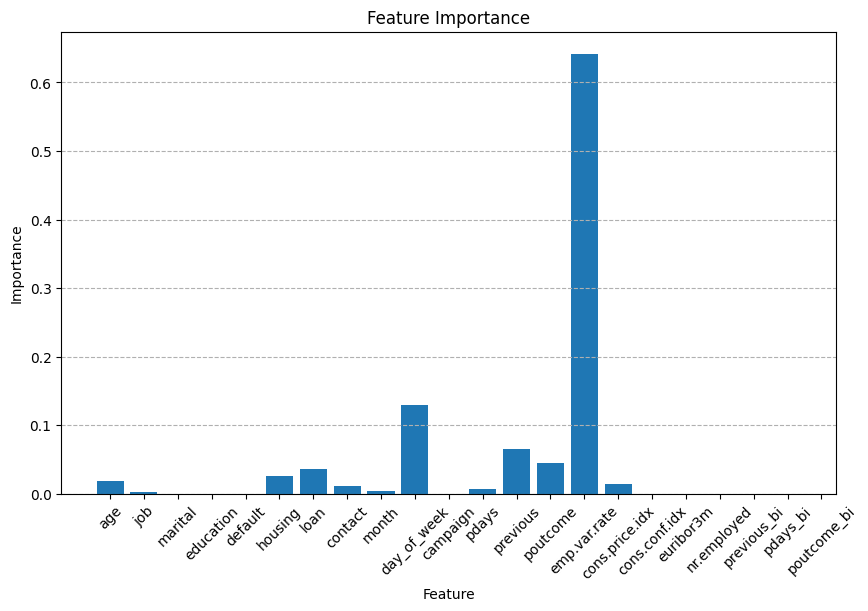

In [ ]:
importances = model.feature_importances_
column_nm = pd.DataFrame(X.columns)
feature_importances = pd.concat([column_nm, pd.DataFrame(importances)], axis=1)
feature_importances.columns = ['feature_nm', 'importances']

# 중요도 시각화 #1

plt.figure(figsize=(10,6))
plt.bar(feature_importances['feature_nm'], feature_importances['importances'])
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importance")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--')
plt.show()

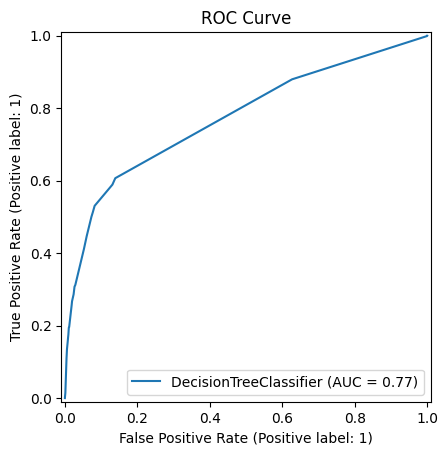

In [ ]:
RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.title("ROC Curve")
plt.show()

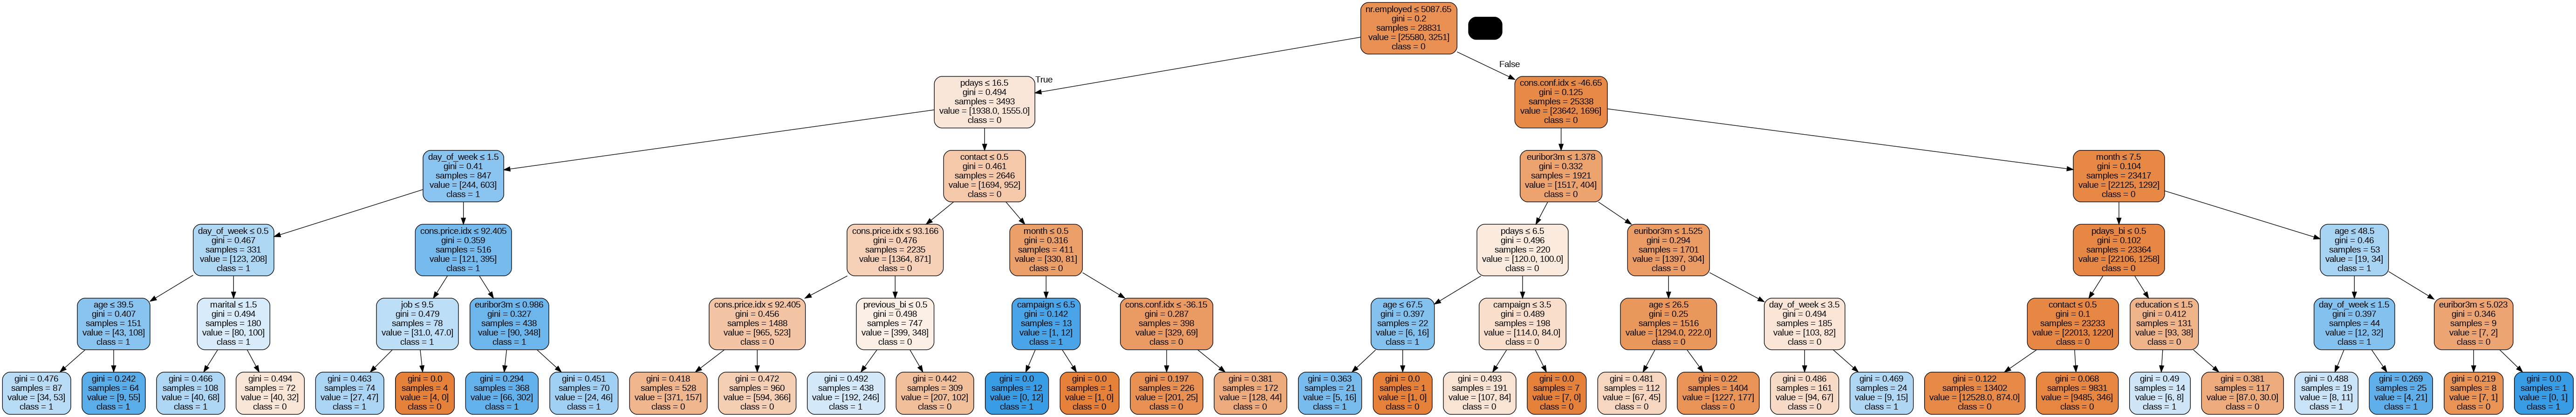

In [ ]:
feature_names = X.columns
target_names = np.array(['0', '1'])

import pydot
import pydotplus
import graphviz
from sklearn.tree import export_graphviz
dt_dot_data = export_graphviz(best_model, feature_names=feature_names,
                              class_names = target_names,
                              filled=True, rounded=True,
                              special_characters=True)
dt_graph = pydotplus.graph_from_dot_data(dt_dot_data)

from IPython.display import Image
Image(dt_graph.create_png())

### Precision: 63.52%
정확도:89.99%

재현율: 25.7%

F1_Score: 36.6%

### Precision높히기

#### 임계값 지정(threshold)

1로 분류할 확률의 최대 최소값을 확인해보자

In [ ]:
y_scores = best_model.predict_proba(X_test)[:,1]
print(max(y_scores))
print(min(y_scores))

1.0
0.0


정밀도와 재현율 시각화

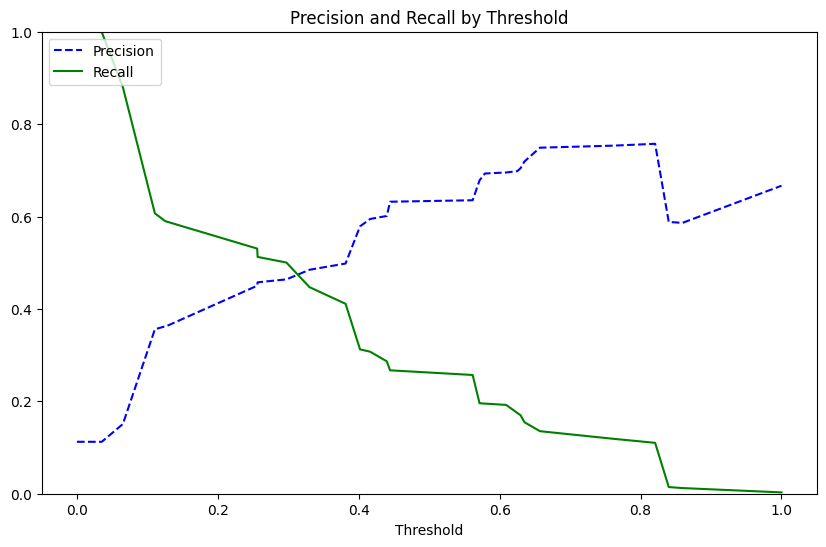

In [ ]:
from sklearn.metrics import precision_recall_curve

# 다양한 임계값에 대한 정밀도, 재현율 계산
precisions, recalls, thresholds = precision_recall_curve(y_test, y_scores)

# 시각화
plt.figure(figsize=(10,6))
plt.plot(thresholds, precisions[:-1], 'b--', label="Precision")
plt.plot(thresholds, recalls[:-1], 'g-', label="Recall")
plt.xlabel("Threshold")
plt.legend(loc="upper left")
plt.ylim([0,1])
plt.title("Precision and Recall by Threshold")
plt.show()

대략 0.32 정도에서 합의를 보는 것 같다.

In [ ]:
threshold = 0.64
pred_custom = (y_scores >= threshold).astype(int)

# 혼동행렬
cm = confusion_matrix(y_test, pred_custom)
print('Confusion Metrix')
print(test_cm)

# 성능지표 계산
acc = accuracy_score(y_test, pred_custom)
prc = precision_score(y_test, pred_custom)
rcll = recall_score(y_test, pred_custom)
f1 = f1_score(y_test, pred_custom)

print('/n')
print("정확도\t{}%".format(round(acc*100,2)))
print("정밀도\t{}%".format(round(prc*100,2)))
print("재현율\t{}%".format(round(rcll*100,2)))
print("F1_Score\t{}%".format(round(f1*100,2)))

Confusion Metrix
[[10763   205]
 [ 1032   357]]
/n
정확도	89.77%
정밀도	74.9%
재현율	13.53%
F1_Score	22.93%


### 정밀도: 74.9%
정확도: 89.77%

재현율: 13.53%

F1_Score: 22.93%

## Decision Tree 7차 학습

In [ ]:
df_7 = df_6.copy()
df_7

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,cons.conf.idx,euribor3m,nr.employed,y,previous_bi,pdays_bi,poutcome_bi,newBi,is_married,earn_bill
0,56,3,1,0,0,0,0,1,6,1,...,-36.4,4.857,5191.0,0,0,0,0,0,1,0
1,57,7,1,3,1,0,0,1,6,1,...,-36.4,4.857,5191.0,0,0,0,0,0,1,1
2,37,7,1,3,0,2,0,1,6,1,...,-36.4,4.857,5191.0,0,0,0,0,0,1,1
3,40,0,1,1,0,0,0,1,6,1,...,-36.4,4.857,5191.0,0,0,0,0,0,1,1
4,56,7,1,3,0,0,2,1,6,1,...,-36.4,4.857,5191.0,0,0,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,5,1,5,0,2,0,0,7,0,...,-50.8,1.028,4963.6,1,0,0,0,0,1,0
41184,46,1,1,5,0,0,0,0,7,0,...,-50.8,1.028,4963.6,0,0,0,0,0,1,1
41185,56,5,1,6,0,2,0,0,7,0,...,-50.8,1.028,4963.6,0,0,0,0,0,1,0
41186,44,9,1,5,0,0,0,0,7,0,...,-50.8,1.028,4963.6,1,0,0,0,0,1,1


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
# 변수 선언
X = df_7.drop('y', axis=1)
y = df_7['y']

# SMOTE
from imblearn.over_sampling import SMOTE
smt = SMOTE()
X_new, y_new = smt.fit_resample(X,y)

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X_new, y_new, test_size=0.3, random_state=42)

# K-Fold 방식 지정
cv = StratifiedKFold(n_splits=7, shuffle=True, random_state=42)

# 하이퍼 파라미터 튜닝

# 파라미터
param_grid = {
    'max_depth': range(5, 20, 1),
    'min_samples_split': range(2, 10, 1)
}

# Grid Search
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=cv,
    scoring='precision'
)

grid_search.fit(X_train, y_train)
print("최적 파라미터:", grid_search.best_params_)
print("최고 교차검증 점수:", grid_search.best_score_)

최적 파라미터: {'max_depth': 8, 'min_samples_split': 8}
최고 교차검증 점수: 0.8932512868438176


In [ ]:
# 최적 모델로 테스트
best_model2 = grid_search.best_estimator_
y_scores = best_model2.predict_proba(X_test)[:,1]

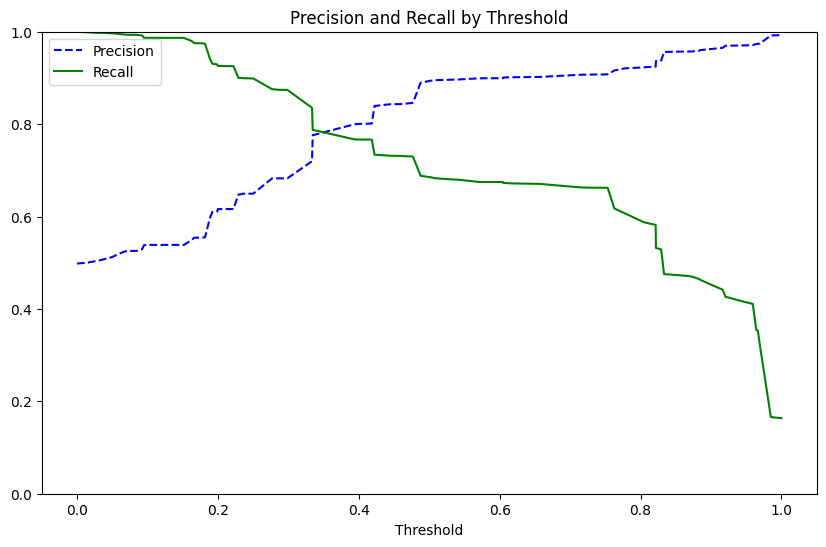

In [ ]:
from sklearn.metrics import precision_recall_curve

# 다양한 임계값에 대한 정밀도, 재현율 계산
precisions, recalls, thresholds = precision_recall_curve(y_test, y_scores)

# 시각화
plt.figure(figsize=(10,6))
plt.plot(thresholds, precisions[:-1], 'b--', label="Precision")
plt.plot(thresholds, recalls[:-1], 'g-', label="Recall")
plt.xlabel("Threshold")
plt.legend(loc="upper left")
plt.ylim([0,1])
plt.title("Precision and Recall by Threshold")
plt.show()

In [ ]:
threshold = 0.5
pred_custom = (y_scores >= threshold).astype(int)

# 혼동행렬
cm = confusion_matrix(y_test, pred_custom)
print('Confusion Metrix')
print(test_cm)

# 성능지표 계산
acc = accuracy_score(y_test, pred_custom)
prc = precision_score(y_test, pred_custom)
rcll = recall_score(y_test, pred_custom)
f1 = f1_score(y_test, pred_custom)

print('/n')
print("정확도\t{}%".format(round(acc*100,2)))
print("정밀도\t{}%".format(round(prc*100,2)))
print("재현율\t{}%".format(round(rcll*100,2)))
print("F1_Score\t{}%".format(round(f1*100,2)))

Confusion Metrix
[[10763   205]
 [ 1032   357]]
/n
정확도	80.25%
정밀도	89.33%
재현율	68.55%
F1_Score	77.57%


여기서 SMOTE라는 것을 활용해 Oversampling된 데이터의 비율을 조정했다.

### 정밀도: 89.33%
정확도: 80.25%

재현율: 68.55%

F1_Score: 77.57%

다른 모델도 한번 적용해보자.

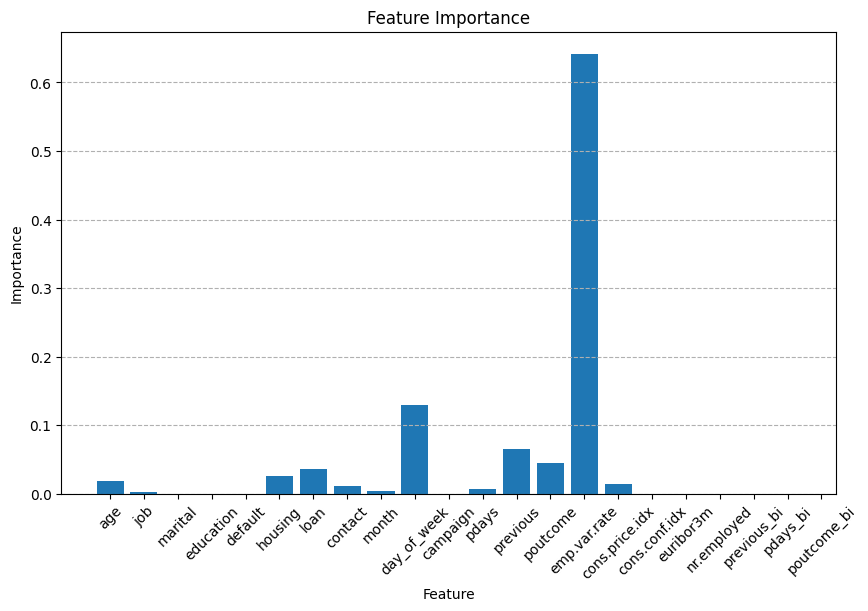

In [ ]:
importances = model.feature_importances_
column_nm = pd.DataFrame(X.columns)
feature_importances = pd.concat([column_nm, pd.DataFrame(importances)], axis=1)
feature_importances.columns = ['feature_nm', 'importances']

# 중요도 시각화 #1

plt.figure(figsize=(10,6))
plt.bar(feature_importances['feature_nm'], feature_importances['importances'])
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importance")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--')
plt.show()

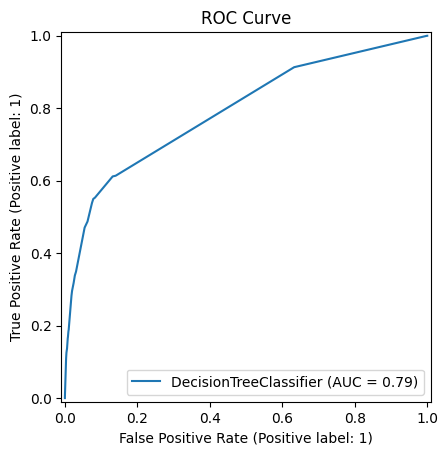

In [ ]:
RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.title("ROC Curve")
plt.show()

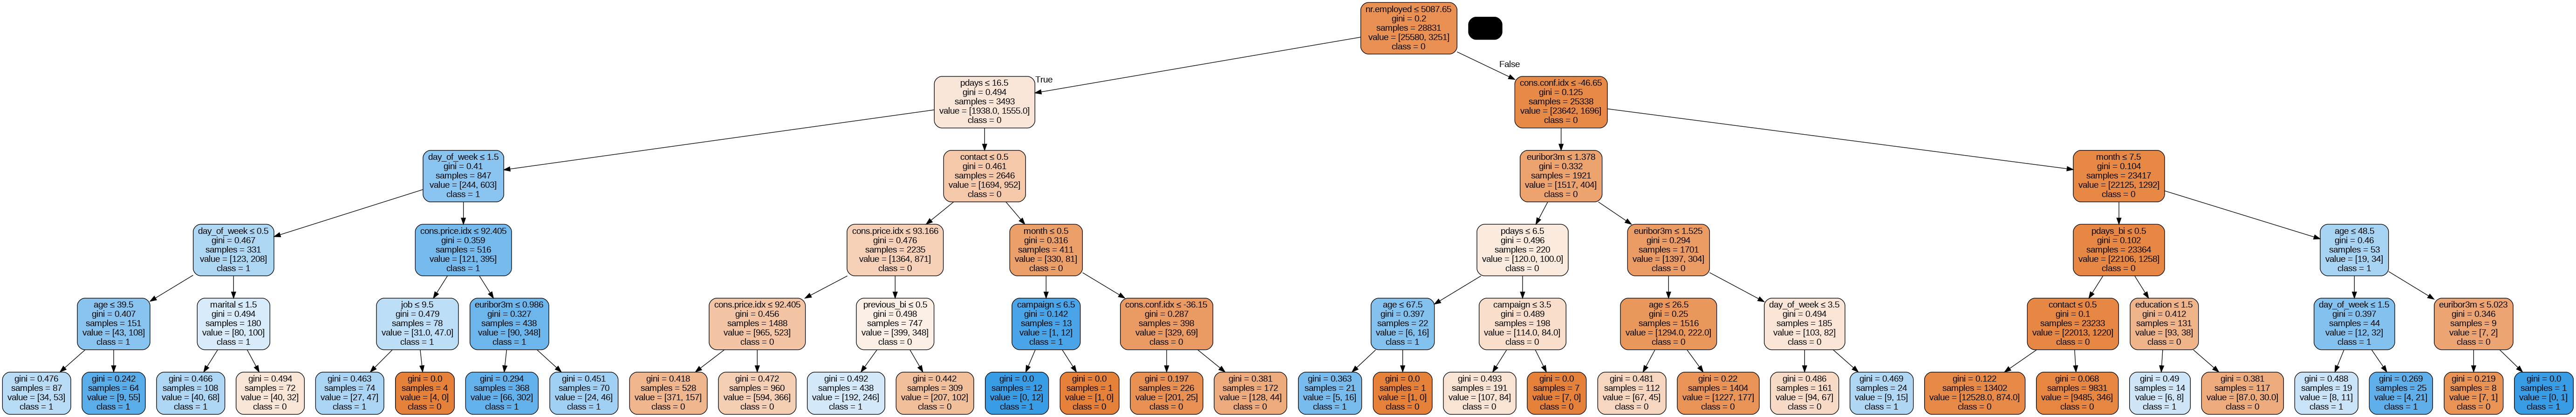

In [ ]:
feature_names = X.columns
target_names = np.array(['0', '1'])

import pydot
import pydotplus
import graphviz
from sklearn.tree import export_graphviz
dt_dot_data = export_graphviz(best_model, feature_names=feature_names,
                              class_names = target_names,
                              filled=True, rounded=True,
                              special_characters=True)
dt_graph = pydotplus.graph_from_dot_data(dt_dot_data)

from IPython.display import Image
Image(dt_graph.create_png())